**Суть проекта:** построить модель классификации транзакций по банковским картам, которая автоматически определяет, является ли операция мошеннической или законной.

Эксперименты на разных этапах, сравнение несколько моделей и подходов к обработке данных, фиксируя промежуточные наблюдения в выводах. Обоснован выбор моделей, гиперпараметров и стратегии оценки качества, проведен разведывательный анализ данных, выполнена предобработка и созданы новые признаки.


## Описание данных

| Название колонки          | Описание                                                                               |
| ------------------------- | -------------------------------------------------------------------------------------- |
| **trans_date_trans_time** | Дата и время совершения транзакции                                                     |
| **cc_num**                | Номер кредитной карты клиента                                                          |
| **merchant**              | Название продавца (торговой точки)                                                     |
| **category**              | Категория транзакции (тип покупки)                                                     |
| **amt**                   | Сумма транзакции                                                                       |
| **first**                 | Имя владельца карты                                                                    |
| **last**                  | Фамилия владельца карты                                                                |
| **gender**                | Пол владельца карты                                                                    |
| **street**                | Адрес совершения транзакции (улица)                                                    |
| **city**                  | Город совершения транзакции                                                            |
| **state**                 | Штат совершения транзакции                                                             |
| **zip**                   | Почтовый индекс                                                                        |
| **lat**                   | Географическая широта места транзакции                                                 |
| **long**                  | Географическая долгота места транзакции                                                |
| **city_pop**              | Население города                                                                       |
| **job**                   | Профессия владельца карты                                                              |
| **dob**                   | Дата рождения владельца карты                                                          |
| **trans_num**             | Уникальный номер транзакции                                                            |
| **unix_time**             | Время транзакции в формате Unix-time                                                   |
| **merch_lat**             | Географическая широта продавца                                                         |
| **merch_long**            | Географическая долгота продавца                                                        |
| **is_fraud**              | Таргет: 1 — мошенническая, 0 — законная |



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)

## Знакомство с данными

In [ ]:
df = pd.read_csv('fraud_dataset.csv') # data_sample_5000.csv #  fraud_dataset.csv

In [ ]:
#df = pd.read_csv('data_sample_5000.csv') # data_sample_5000.csv #  fraud_dataset.csv

In [ ]:
# sample_df = df.sample(n=50000, random_state=42)
# sample_df.to_csv('data_sample_5000.csv', index=False, encoding='utf-8')
# print(f"Сохранено {len(sample_df)} строк в файл 'data_sample_50000.csv'")

In [ ]:
df.shape

(1852394, 22)

In [ ]:
amount_of_attribute_begin = df.shape[1]

In [ ]:
df.describe()

,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06
mean,4.173860e+17,7.006357e+01,4.881326e+04,3.853931e+01,-9.022783e+01,8.864367e+04,1.358674e+09,3.853898e+01,-9.022794e+01,5.210015e-03
std,1.309115e+18,1.592540e+02,2.688185e+04,5.071470e+00,1.374789e+01,3.014876e+05,1.819508e+07,5.105604e+00,1.375969e+01,7.199217e-02
min,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902742e+01,-1.666716e+02,0.000000e+00
25%,1.800429e+14,9.640000e+00,2.623700e+04,3.466890e+01,-9.679800e+01,7.410000e+02,1.343017e+09,3.474012e+01,-9.689944e+01,0.000000e+00
50%,3.521417e+15,4.745000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.443000e+03,1.357089e+09,3.936890e+01,-8.744069e+01,0.000000e+00
75%,4.642255e+15,8.310000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.374581e+09,4.195626e+01,-8.024511e+01,0.000000e+00
max,4.992346e+18,2.894890e+04,9.992100e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.388534e+09,6.751027e+01,-6.695090e+01,1.000000e+00


In [ ]:
columns = ['cc_num', 'amt', 'zip', 'lat', 'long', 'city_pop', 'merch_lat', 'merch_long']

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1852394 entries, 0 to 1852393
Data columns (total 22 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   trans_date_trans_time  object 
 1   cc_num                 int64  
 2   merchant               object 
 3   category               object 
 4   amt                    float64
 5   first                  object 
 6   last                   object 
 7   gender                 object 
 8   street                 object 
 9   city                   object 
 10  state                  object 
 11  zip                    int64  
 12  lat                    float64
 13  long                   float64
 14  city_pop               int64  
 15  job                    object 
 16  dob                    object 
 17  trans_num              object 
 18  unix_time              int64  
 19  merch_lat              float64
 20  merch_long             float64
 21  is_fraud               int64  
dtypes: float64(5), int

In [ ]:
df.sample(5)

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
1757833,2020-12-11 04:19:47,343668971234893,fraud_Kihn Inc,shopping_pos,689.82,Sally,Moore,F,835 Reese Views Suite 884,Hopkins,SC,29061,33.9349,-80.8449,13717,Chiropodist,1949-11-16,a9f009b59a45c9b6a2cf7107c4819804,1386735587,34.478569,-80.883419,0
791278,2019-12-02 06:00:06,4935858973307492,fraud_Schmeler Inc,misc_pos,33.59,Lance,Wagner,M,6003 Brady Shoal Apt. 449,Irwinton,GA,31042,32.8088,-83.1740,1841,Film/video editor,1975-06-01,a533d41dac1b3047bf3265fa69cdc21a,1354428006,33.637279,-83.593203,0
1808639,2020-12-22 01:23:25,4992346398065154184,"fraud_Stroman, Hudson and Erdman",gas_transport,79.87,Benjamin,Kim,M,920 Patrick Light,Mc Nabb,IL,61335,41.1730,-89.2187,532,Audiological scientist,1956-01-09,c6532edcd8c0500acba548ba4a31f4e4,1387675405,41.733036,-88.668822,0
213793,2019-04-19 12:16:19,6511349151405438,fraud_Kirlin and Sons,personal_care,83.64,Robert,Nguyen,M,74835 Garner Point,Ruth,NV,89319,39.3426,-114.8859,450,Interpreter,1946-08-24,5a4df4a924430fab4db6ea80c46f9ead,1334837779,39.462612,-114.615749,0
677312,2019-10-15 15:30:06,3558652751678952,"fraud_Metz, Russel and Metz",kids_pets,12.50,Teresa,Blankenship,F,6638 Lucero Mill Suite 952,Karnack,TX,75661,32.6205,-94.2000,2807,Chiropodist,1931-01-26,57d3f70e27f6efbed488ba840b4a9538,1350315006,31.682245,-94.844336,0


In [ ]:
# Изменение типа данных unix_time. Видимо надо удалить, так как дублирует trans_date_trans_time с 2012 годом.
df['unix_time'] = pd.to_datetime(df['unix_time'], unit='s')

In [ ]:
# Находим все дублирующиеся строки (все копии, включая первую)
duplicates = df[df.duplicated(keep=False)]

print("Количество дублирующихся строк:", len(duplicates))

Количество дублирующихся строк: 0


In [ ]:
df['is_fraud'] = df['is_fraud'].astype('bool')

In [ ]:
print("Тип данных столбца 'is_fraud':", df['is_fraud'].dtype)
print("Уникальные значения:", df['is_fraud'].unique())
print("Распределение классов:")
print(df['is_fraud'].value_counts())
print("Количество пропусков:", df['is_fraud'].isna().sum())
print(df.shape)

Тип данных столбца 'is_fraud': bool
Уникальные значения: [False  True]
Распределение классов:
is_fraud
False    1842743
True        9651
Name: count, dtype: int64
Количество пропусков: 0
(1852394, 22)


In [ ]:
df.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat',
       'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat',
       'merch_long', 'is_fraud'],
      dtype='object')

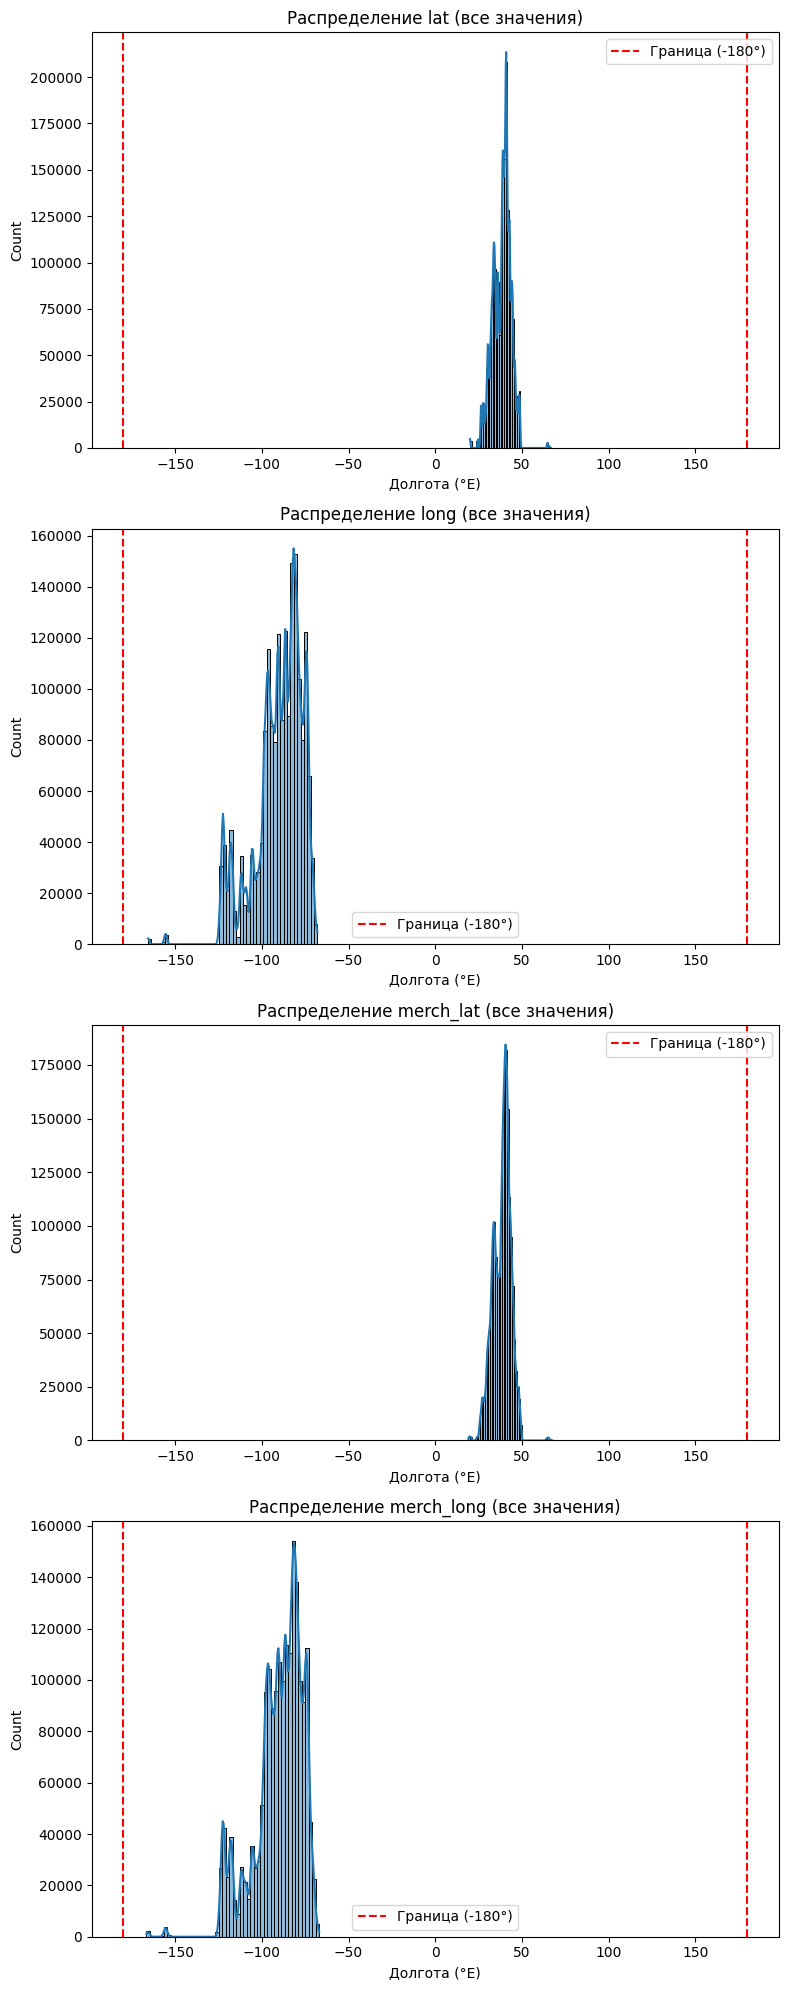

ИТОГОВЫЙ ОТЧЁТ ПО ПРОВЕРКЕ ДОЛГОТЫ
lat:
  Корректных: 1852394 (100.0%)
  Некорректных: 0 (0.0%)
long:
  Корректных: 1852394 (100.0%)
  Некорректных: 0 (0.0%)
merch_lat:
  Корректных: 1852394 (100.0%)
  Некорректных: 0 (0.0%)
merch_long:
  Корректных: 1852394 (100.0%)
  Некорректных: 0 (0.0%)


In [ ]:
# Проверим, что значения долготы находятся в диапазоне [-180°, +180°].

def check_longitude_range(df, columns=None, plot_results=True):
    """
    Проверяет, что значения долготы находятся в диапазоне [-180°, +180°].
    Возвращает: словарь с информацией о проблемах.
    """
    if columns is None:
        columns = ['lat', 'long', 'merch_lat', 'merch_long']

    results = {}

    for col in columns:
        # Проверяем существование столбца
        if col not in df.columns:
            print(f"Столбец '{col}' не найден в датафрейме.")
            continue

        #df[col] = pd.to_numeric(df[col], errors='coerce')

        # Определяем границы
        min_valid = -180
        max_valid = 180

        # Находим некорректные значения
        invalid_mask = (df[col] < min_valid) | (df[col] > max_valid)
        invalid_values = df[df[col].notna() & invalid_mask][col]
        valid_values = df[~invalid_mask][col]

        # Собираем статистику
        total_count = len(df[col].dropna())
        invalid_count = len(invalid_values)
        valid_count = total_count - invalid_count
        invalid_percentage = (invalid_count / total_count * 100) if total_count > 0 else 0

        results[col] = {
            'total': total_count,
            'valid': valid_count,
            'invalid': invalid_count,
            'invalid_percentage': invalid_percentage,
            'invalid_values': invalid_values
        }

    if plot_results and columns:
        plot_longitude_distribution(df, columns)


    return results

def plot_longitude_distribution(df, columns):
    """Строит графики распределения долготы для указанных столбцов."""
    n_cols = len(columns)
    plt.figure(figsize=(15, 5 * n_cols))

    for i, col in enumerate(columns, 1):
        if col in df.columns:
            plt.subplot(n_cols, 2, 2*i-1)
            # Гистограмма всех значений
            sns.histplot(df[col].dropna(), bins=50, kde=True)
            plt.axvline(x=-180, color='red', linestyle='--', label='Граница (-180°)')
            plt.axvline(x=180, color='red', linestyle='--')
            plt.title(f'Распределение {col} (все значения)')
            plt.xlabel('Долгота (°E)')
            plt.legend()


    plt.tight_layout()
    plt.show()

# Запуск проверки
results = check_longitude_range(df)

# Итоговый отчёт
print("ИТОГОВЫЙ ОТЧЁТ ПО ПРОВЕРКЕ ДОЛГОТЫ")
for col, data in results.items():
    print(f"{col}:")
    print(f"  Корректных: {data['valid']} ({data['valid']/data['total']*100:.1f}%)")
    print(f"  Некорректных: {data['invalid']} ({data['invalid_percentage']:.1f}%)")


**Вывод по пункту 1:**


- **Размер и период.** В датасете 1 852 394 строки и 22 столбца. Если посмотреть на `trans_date_trans_time`, данные охватывают период с `2019-01-01` по `2019-03-11`. Это много данных и достаточно длинный временной горизонт — для обучения ML-моделей этого вполне достаточно.
- **Пропуски.** Явных пропусков в значимых столбцах практически нет (`isna().sum()` по таргету = 0). Пропуски, которые появятся позже (`time_diff_prev` у первой транзакции каждой карты, `age_*`), — это следствие feature engineering, их обработаем на этапе подготовки.
- **Дубли.** Полных дублей строк нет (`duplicated` = 0), что логично — каждая транзакция уникальна (`trans_num`).
- **Типы данных.** `trans_date_trans_time` и `dob` хранятся как строки — их нужно привести к datetime. `is_fraud` удобно сделать булевым. `unix_time` дублирует `trans_date_trans_time`, поэтому его можно удалить.
- **Неинформативные столбцы.** `trans_num` — уникальный идентификатор (бесполезен для модели). `first`, `last`, `street` — персональные идентификаторы (риск переобучения/утечки). Высококардинальные `merchant`, `city`, `job`, `cc_num` потребуют отдельной обработки.
- **Выбросы.** В `amt` и `city_pop` есть длинные правые хвосты (max `amt` ≈ 28949 при медиане ≈ 47). Пока ничего не удаляем — экстремальные суммы могут быть как раз индикатором фрода.
- **Географические данные.** Значения `lat`/`long`/`merch_lat`/`merch_long` все в корректном диапазоне (проверка показала 0 некорректных).
- **Дисбаланс.** Доля fraud-транзакций ≈ 0.52% — сильный дисбаланс классов, его надо учитывать при выборе метрики и стратегии обучения.

## 2. Расширение данных

1. Исправить типы столбцов и распарсить те, что являются мультипризнаковыми (при наличии).
2. Обработка высококардинальных признаков.
3. Создать новые временные признаки на основе `trans_date_trans_time`.
4. Обучить алгоритмы кластеризации на признаках `lat`+`long` и `merch_lat`+`merch_long`, полученные фичи будут отражать соответствующий географический кластер.
5. Сформировать признак возраста на основе `dob`.
6. Обработайте пропуски и ошибочные значения, удалите дубли и неинформативные признаки на этом этапе.

In [ ]:
# Изменение типа данных trans_date_trans_time
df['trans_date_trans_time'] = pd.to_datetime(
    df['trans_date_trans_time'],
    format='%Y-%m-%d %H:%M:%S'
)

In [ ]:
df.shape

(1852394, 22)

In [ ]:
from collections import Counter

def analyze_high_cardinality_features(df, high_card_threshold=1000):
    """
    Анализирует высококардинальные признаки и предлагает стратегии обработки.
    Возвращает: словарь с результатами анализа.
    """
    results = {}
    high_card_features = []

    for col in df.columns:
        # Пропускаем числовые столбцы и целевой признак
        if df[col].dtype in [#'int64',
                             'float64', 'datetime64[ns]'] or col == 'is_fraud':
            continue

        # Считаем уникальные значения
        unique_count = df[col].nunique()
        total_count = len(df)
        unique_ratio = unique_count / total_count

        results[col] = {
            'unique_values': unique_count,
            'total_rows': total_count,
            'unique_ratio': unique_ratio,
            'is_high_cardinality': unique_count > high_card_threshold
        }

        if results[col]['is_high_cardinality']:
            high_card_features.append(col)

    return results, high_card_features

# Запускаем анализ
analysis_results, high_card_features = analyze_high_cardinality_features(df)

# Выводим результаты
print("АНАЛИЗ ВЫСОКОКАРДИНАЛЬНЫХ ПРИЗНАКОВ")
for col, data in analysis_results.items():
    status = "ВЫСОКАЯ КАРДИНАЛЬНОСТЬ" if data['is_high_cardinality'] else "НОРМАЛЬНАЯ"
    print(f"{col}:")
    print(f"  Уникальных значений: {data['unique_values']}")
    print(f"  Всего строк: {data['total_rows']}")
    print(f"  Доля уникальных: {data['unique_ratio']:.3f}")
    print(f"  Статус: {status}")
    print("-" * 30)

print(f"\nВысококардинальные признаки (>{1000} уникальных): {high_card_features}")

АНАЛИЗ ВЫСОКОКАРДИНАЛЬНЫХ ПРИЗНАКОВ
cc_num:
  Уникальных значений: 999
  Всего строк: 1852394
  Доля уникальных: 0.001
  Статус: НОРМАЛЬНАЯ
------------------------------
merchant:
  Уникальных значений: 693
  Всего строк: 1852394
  Доля уникальных: 0.000
  Статус: НОРМАЛЬНАЯ
------------------------------
category:
  Уникальных значений: 14
  Всего строк: 1852394
  Доля уникальных: 0.000
  Статус: НОРМАЛЬНАЯ
------------------------------
first:
  Уникальных значений: 355
  Всего строк: 1852394
  Доля уникальных: 0.000
  Статус: НОРМАЛЬНАЯ
------------------------------
last:
  Уникальных значений: 486
  Всего строк: 1852394
  Доля уникальных: 0.000
  Статус: НОРМАЛЬНАЯ
------------------------------
gender:
  Уникальных значений: 2
  Всего строк: 1852394
  Доля уникальных: 0.000
  Статус: НОРМАЛЬНАЯ
------------------------------
street:
  Уникальных значений: 999
  Всего строк: 1852394
  Доля уникальных: 0.001
  Статус: НОРМАЛЬНАЯ
------------------------------
city:
  Уникальных зн

In [ ]:
# Удаляем абсолютно уникальные идентификаторы
features_to_drop = high_card_features

# Проверяем cc_num: если почти все уникальны — тоже удаляем
if analysis_results['cc_num']['unique_ratio'] > 0.95:
    features_to_drop.append('cc_num')

df = df.drop(columns=features_to_drop)
print(f"Удалены признаки: {features_to_drop}")


Удалены признаки: ['trans_num']


In [ ]:
# Извлекаем компоненты даты и времени
df['transaction_year'] = df['trans_date_trans_time'].dt.year
df['transaction_month'] = df['trans_date_trans_time'].dt.month
df['transaction_day'] = df['trans_date_trans_time'].dt.day
df['transaction_hour'] = df['trans_date_trans_time'].dt.hour
df['transaction_minute'] = df['trans_date_trans_time'].dt.minute
df['transaction_weekday'] = df['trans_date_trans_time'].dt.weekday  # 0=понедельник, 6=воскресенье
df['transaction_day_of_year'] = df['trans_date_trans_time'].dt.dayofyear
df['transaction_quarter'] = df['trans_date_trans_time'].dt.quarter

In [ ]:
# Признаки для анализа активности по времени суток
# Время суток (категориальный признак)
def get_time_of_day(hour):
    if 5 <= hour < 12:
        return 'morning'
    elif 12 <= hour < 17:
        return 'afternoon'
    elif 17 <= hour < 22:
        return 'evening'
    else:
        return 'night'

df['time_of_day'] = df['transaction_hour'].apply(get_time_of_day)

# Признак «рабочий час» (8:00–18:00)
df['is_business_hour'] = ((df['transaction_hour'] >= 8) & (df['transaction_hour'] < 18)).astype(int)

# Ночные транзакции (22:00–5:00) — потенциально подозрительные
df['is_night_transaction'] = (
    (df['transaction_hour'] >= 22) | (df['transaction_hour'] < 5)
).astype(int)


In [ ]:
# Признаки для анализа дней недели и выходных

days_of_week = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['day_of_week_name'] = df['transaction_weekday'].map(lambda x: days_of_week[x])

# Признак выходного дня
df['is_weekend'] = (df['transaction_weekday'] >= 5).astype(int)  # 5=суббота, 6=воскресенье

# Будни
df['is_weekday'] = (df['transaction_weekday'] < 5).astype(int)


In [ ]:
# Сезонные и праздничные признаки

# Сезон года
def get_season(month):
    if month in [12, 1, 2]:
        return 'winter'
    elif month in [3, 4, 5]:
        return 'spring'
    elif month in [6, 7, 8]:
        return 'summer'
    else:
        return 'autumn'

df['season'] = df['transaction_month'].apply(get_season)

# Праздничные периоды
df['is_holiday_season'] = (
    (df['transaction_month'] == 12) |  # декабрь
    ((df['transaction_month'] == 1) & (df['transaction_day'] <= 12))  # начало января
).astype(int)


In [ ]:
# Временные интервалы между транзакциями

# Сортируем по карте и времени
df = df.sort_values(['cc_num', 'trans_date_trans_time'])

# Разница во времени между последовательными транзакциями для одной карты
df['time_diff_prev'] = df.groupby('cc_num')['trans_date_trans_time'].diff().dt.total_seconds() / 3600  # в часах

# Признак быстрой повторной транзакции (<5 минут)
df['is_rapid_repeat'] = (df['time_diff_prev'] * 60 < 5).astype(int)  # <5 минут


In [ ]:
# Проверка созданных признаков
print("=== СОЗДАННЫЕ ВРЕМЕННЫЕ ПРИЗНАКИ ===")
print(f"Всего строк: {len(df)}")
print("\nПервые 5 строк с новыми признаками:")
print(df[[
    'trans_date_trans_time', 'transaction_year', 'transaction_month',
    'transaction_day', 'transaction_hour', 'transaction_weekday',
    'time_of_day', 'is_weekend', 'season', #'recent_transactions_24h',
    'time_diff_prev'
]].head())

print("\nСтатистика по новым категориальным признакам:")
categorical_features = ['time_of_day', 'season', 'day_of_week_name']
for col in categorical_features:
    if col in df.columns:
        print(f"\n{col}:")
        print(df[col].value_counts())


=== СОЗДАННЫЕ ВРЕМЕННЫЕ ПРИЗНАКИ ===
Всего строк: 1852394

Первые 5 строк с новыми признаками:
     trans_date_trans_time  transaction_year  transaction_month  \
1017   2019-01-01 12:47:15              2019                  1   
2724   2019-01-02 08:44:57              2019                  1   
2726   2019-01-02 08:47:36              2019                  1   
2882   2019-01-02 12:38:14              2019                  1   
2907   2019-01-02 13:10:46              2019                  1   

      transaction_day  transaction_hour  transaction_weekday time_of_day  \
1017                1                12                    1   afternoon   
2724                2                 8                    2     morning   
2726                2                 8                    2     morning   
2882                2                12                    2   afternoon   
2907                2                13                    2   afternoon   

      is_weekend  season  time_diff_prev  
10

In [ ]:
from datetime import datetime

df['dob'] = pd.to_datetime(df['dob'], errors='coerce')

def calculate_age(birth_date):
    """Рассчитывает возраст в полных годах на текущую дату."""
    if pd.isna(birth_date):
        return None
    today = datetime.now().date()
    birth_date = birth_date.date()

    # Основной расчёт: разница в годах
    age = today.year - birth_date.year

    # Корректировка: если день рождения ещё не наступил в этом году
    if (today.month, today.day) < (birth_date.month, birth_date.day):
        age -= 1
    return age

# Применяем функцию к столбцу dob
df['age_exact'] = df['dob'].apply(calculate_age)

# Сначала рассчитываем точный возраст
df['age_exact'] = df['dob'].apply(calculate_age)

# Создаём категории возраста
bins = [0, 18, 25, 35, 45, 55, 65, 100]
labels = [
    '0–17', '18–24', '25–34', '35–44',
    '45–54', '55–64', '65+'
]

df['age_category'] = pd.cut(df['age_exact'], bins=bins, labels=labels, right=False)


Статистика по возрасту:
count    1.852394e+06
mean     5.217376e+01
std      1.740260e+01
min      2.100000e+01
25%      3.900000e+01
50%      5.000000e+01
75%      6.300000e+01
max      1.010000e+02
Name: age_exact, dtype: float64

Распределение по категориям:
age_category
0–17          0
18–24     27816
25–34    248110
35–44    437977
45–54    429070
55–64    282861
65+      425814
Name: count, dtype: int64


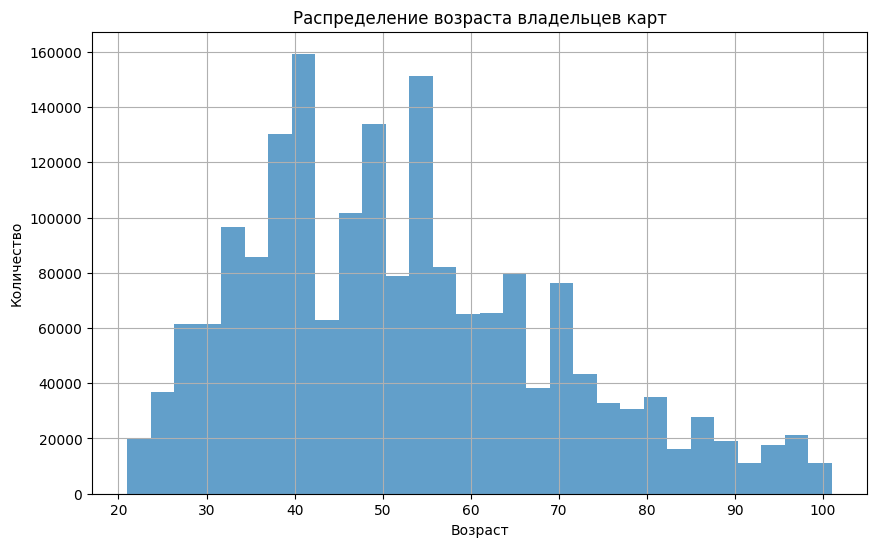

In [ ]:
print("Статистика по возрасту:")
print(df['age_exact'].describe())

print("\nРаспределение по категориям:")
print(df['age_category'].value_counts().sort_index())

# Визуализация
plt.figure(figsize=(10, 6))
df['age_exact'].hist(bins=30, alpha=0.7)
plt.title('Распределение возраста владельцев карт')
plt.xlabel('Возраст')
plt.ylabel('Количество')
plt.show()


In [ ]:
new_attribute = df.shape[1] - amount_of_attribute_begin
print(f'Новых признаков: {new_attribute}')

Новых признаков: 19


**Вывод:**

На этом этапе было сделано:
- Изменение типа данных на datetime
- Проанализировано высококардинальные признаки
- Удалены абсолютно уникальные идентификаторы
- Извлечены компоненты даты и времени
- Рассчитан возраст в полных годах на текущую дату

## 3. Исследование данных

Приступим к EDA:

1. Баланс классов.
2. Мультиколлинеарность для числовых / проверка связанности для категориальных признаков.
3. Распределения признаков — как числовых, так и категориальных, в т. ч. в разрезе классов.
4. Парные зависимости.
5. Применить статистические гипотезы.

Распределение классов:
Класс False: 1842743 записей (99.48%)
Класс True: 9651 записей (0.52%)


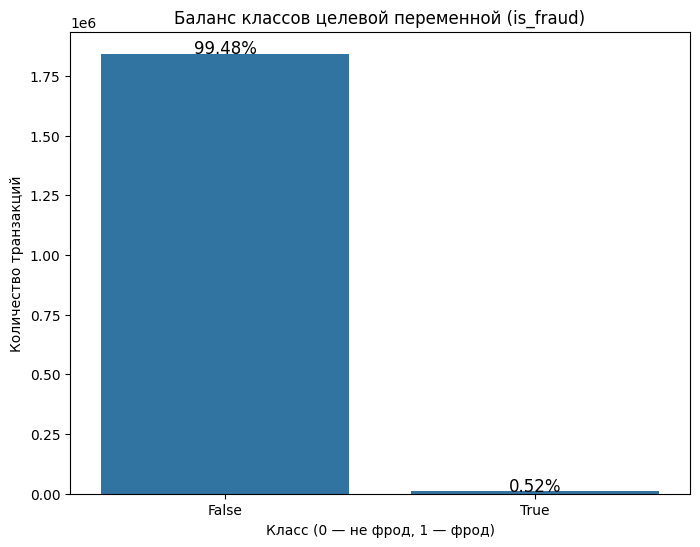

In [ ]:
# Распределение классов
target_counts = df['is_fraud'].value_counts()
target_percentages = df['is_fraud'].value_counts(normalize=True) * 100

print("Распределение классов:")
for label, count in target_counts.items():
    percentage = target_percentages[label]
    print(f"Класс {label}: {count} записей ({percentage:.2f}%)")

# Визуализация баланса классов
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='is_fraud')
plt.title('Баланс классов целевой переменной (is_fraud)')
plt.ylabel('Количество транзакций')
plt.xlabel('Класс (0 — не фрод, 1 — фрод)')

# Добавляем проценты на график
for i, p in enumerate(plt.gca().patches):
    height = p.get_height()
    percentage = (height / len(df)) * 100
    plt.text(p.get_x() + p.get_width() / 2., height + 50,
             f'{percentage:.2f}%', ha='center', fontsize=12)
plt.show()


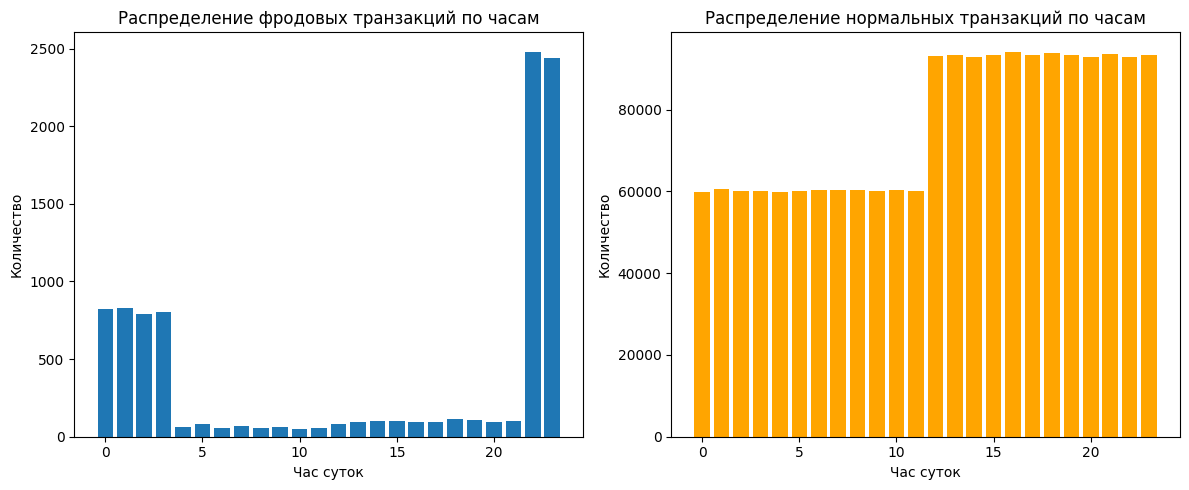

In [ ]:
# Преобразуем дату, если нужно
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

# Извлекаем временные признаки
df['hour'] = df['trans_date_trans_time'].dt.hour
df['day_of_week'] = df['trans_date_trans_time'].dt.dayofweek
df['month'] = df['trans_date_trans_time'].dt.month

# Распределение транзакций по часам для каждого класса
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
hourly_fraud = df[df['is_fraud'] == 1]['hour'].value_counts().sort_index()
plt.bar(hourly_fraud.index, hourly_fraud.values)
plt.title('Распределение фродовых транзакций по часам')
plt.xlabel('Час суток')
plt.ylabel('Количество')

plt.subplot(1, 2, 2)
hourly_normal = df[df['is_fraud'] == 0]['hour'].value_counts().sort_index()
plt.bar(hourly_normal.index, hourly_normal.values, color='orange')
plt.title('Распределение нормальных транзакций по часам')
plt.xlabel('Час суток')
plt.ylabel('Количество')

plt.tight_layout()
plt.show()


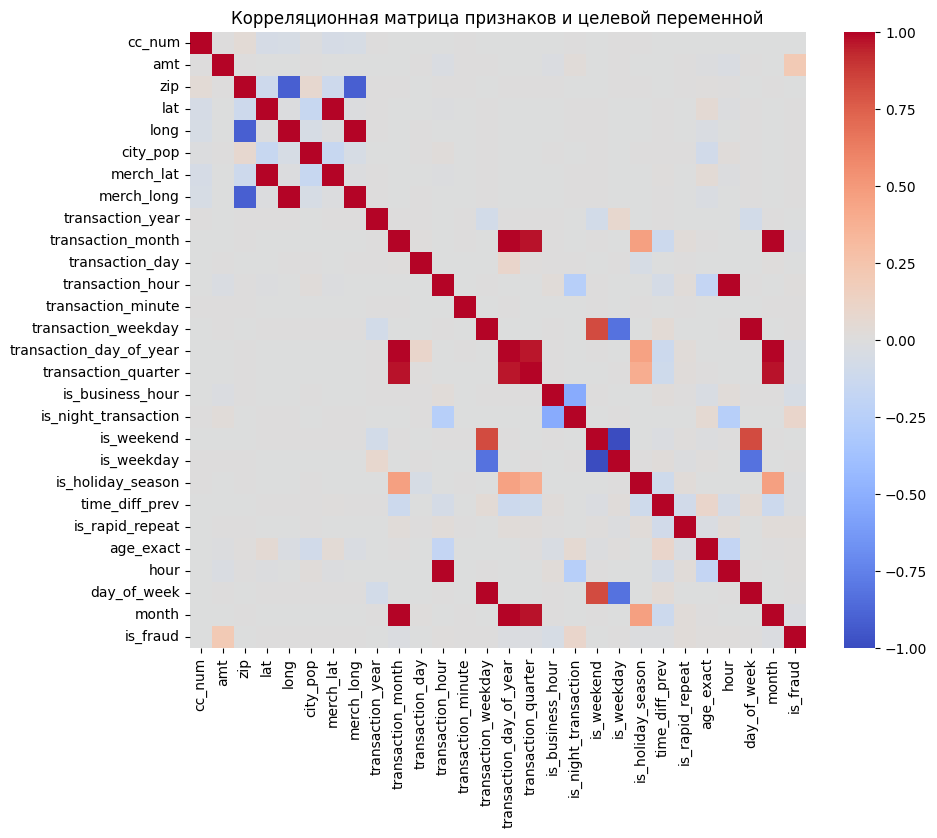

Топ-корреляции с целевой переменной:
amt                     0.209308
is_night_transaction    0.095767
is_business_hour        0.051153
is_rapid_repeat         0.027690
transaction_month       0.016417
Name: is_fraud, dtype: float64


In [ ]:
# Корреляционная матрица для числовых признаков + целевая переменная
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_features = [f for f in numeric_features if f != 'is_fraud']   # исключаем целевую переменную

corr_matrix = df[numeric_features + ['is_fraud']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, #annot=True,
            cmap='coolwarm', center=0,
           square=True, fmt='.2f')
plt.title('Корреляционная матрица признаков и целевой переменной')
plt.show()

# Топ-корреляции с целевой переменной
correlations_with_target = corr_matrix['is_fraud'].abs().sort_values(ascending=False)
print("Топ-корреляции с целевой переменной:")
print(correlations_with_target[1:6])  # Исключаем саму целевую переменную


Видно, что признаки дат сильно коррелируют между собой, а не с таргетом. Пока удалять их не буду по причинам:
- Отсутствие влияния на целевую переменную.
- Сохранение информации. Удаление признаков ведёт к потере информации, которая может быть важна для модели, даже если эти признаки коррелируют между собой.
- Тип модели. Для нелинейных моделей или ансамблей (например, случайных лесов, градиентного бустинга) мультиколлинеарность часто не является критичной проблемой. Эти модели могут автоматически выбирать наиболее информативные признаки, игнорируя избыточные. Если для baseline линейной модели это будет проблемой, удалим.

In [ ]:
from scipy.stats import chi2_contingency

categorical_features = df.select_dtypes(include=['object']).columns.tolist()

chi2_results = []

for i in range(len(categorical_features)):
    for j in range(i+1, len(categorical_features)):
        feature1, feature2 = categorical_features[i], categorical_features[j]

        # Создаём таблицу сопряжённости
        contingency_table = pd.crosstab(
            df[feature1],
            df[feature2]
        )

        # Тест хи‑квадрат
        chi2, p_value, dof, expected = chi2_contingency(contingency_table)

        chi2_results.append({
            'feature1': feature1,
            'feature2': feature2,
            'chi2': chi2,
            'p_value': p_value
        })

# Выводим значимые связи (p‑value < 0.05)
significant_associations = [
    r for r in chi2_results if r['p_value'] < 0.05
]

# Фильтруем результаты, оставляя только пары с p‑value < 0.05 (уровень значимости 5 %).
# если p_value < 0.05, связь между признаками статистически значима (гипотеза независимости отвергается);
# если p_value ≥ 0.05, признаков независимы (нет оснований отвергать нулевую гипотезу).
print("Значимые связи между категориальными признаками (p < 0.05):")
for assoc in significant_associations:
    print(
        f"{assoc['feature1']} — {assoc['feature2']}: "
        f"χ² = {assoc['chi2']:.2f}, p = {assoc['p_value']:.6f}"
    )


Значимые связи между категориальными признаками (p < 0.05):
merchant — category: χ² = 23821955.43, p = 0.000000
merchant — first: χ² = 288110.28, p = 0.000000
merchant — last: χ² = 386203.11, p = 0.000000
merchant — gender: χ² = 6008.00, p = 0.000000
merchant — street: χ² = 787626.95, p = 0.000000
merchant — city: χ² = 718513.07, p = 0.000000
merchant — state: χ² = 43550.88, p = 0.000000
merchant — job: χ² = 398410.55, p = 0.000000
merchant — time_of_day: χ² = 894810.53, p = 0.000000
category — first: χ² = 49868.44, p = 0.000000
category — last: χ² = 58928.08, p = 0.000000
category — gender: χ² = 5407.24, p = 0.000000
category — street: χ² = 114813.73, p = 0.000000
category — city: χ² = 107751.45, p = 0.000000
category — state: χ² = 9421.63, p = 0.000000
category — job: χ² = 62987.16, p = 0.000000
category — time_of_day: χ² = 901125.77, p = 0.000000
category — day_of_week_name: χ² = 166.92, p = 0.000000
category — season: χ² = 58.55, p = 0.022893
first — last: χ² = 331405446.64, p = 0.

Тест хи‑квадрат помогает выявить скрытые зависимости между категориальными переменными. Значение p близко к 0 по многим парам, поэтому будем проверять все признаки.

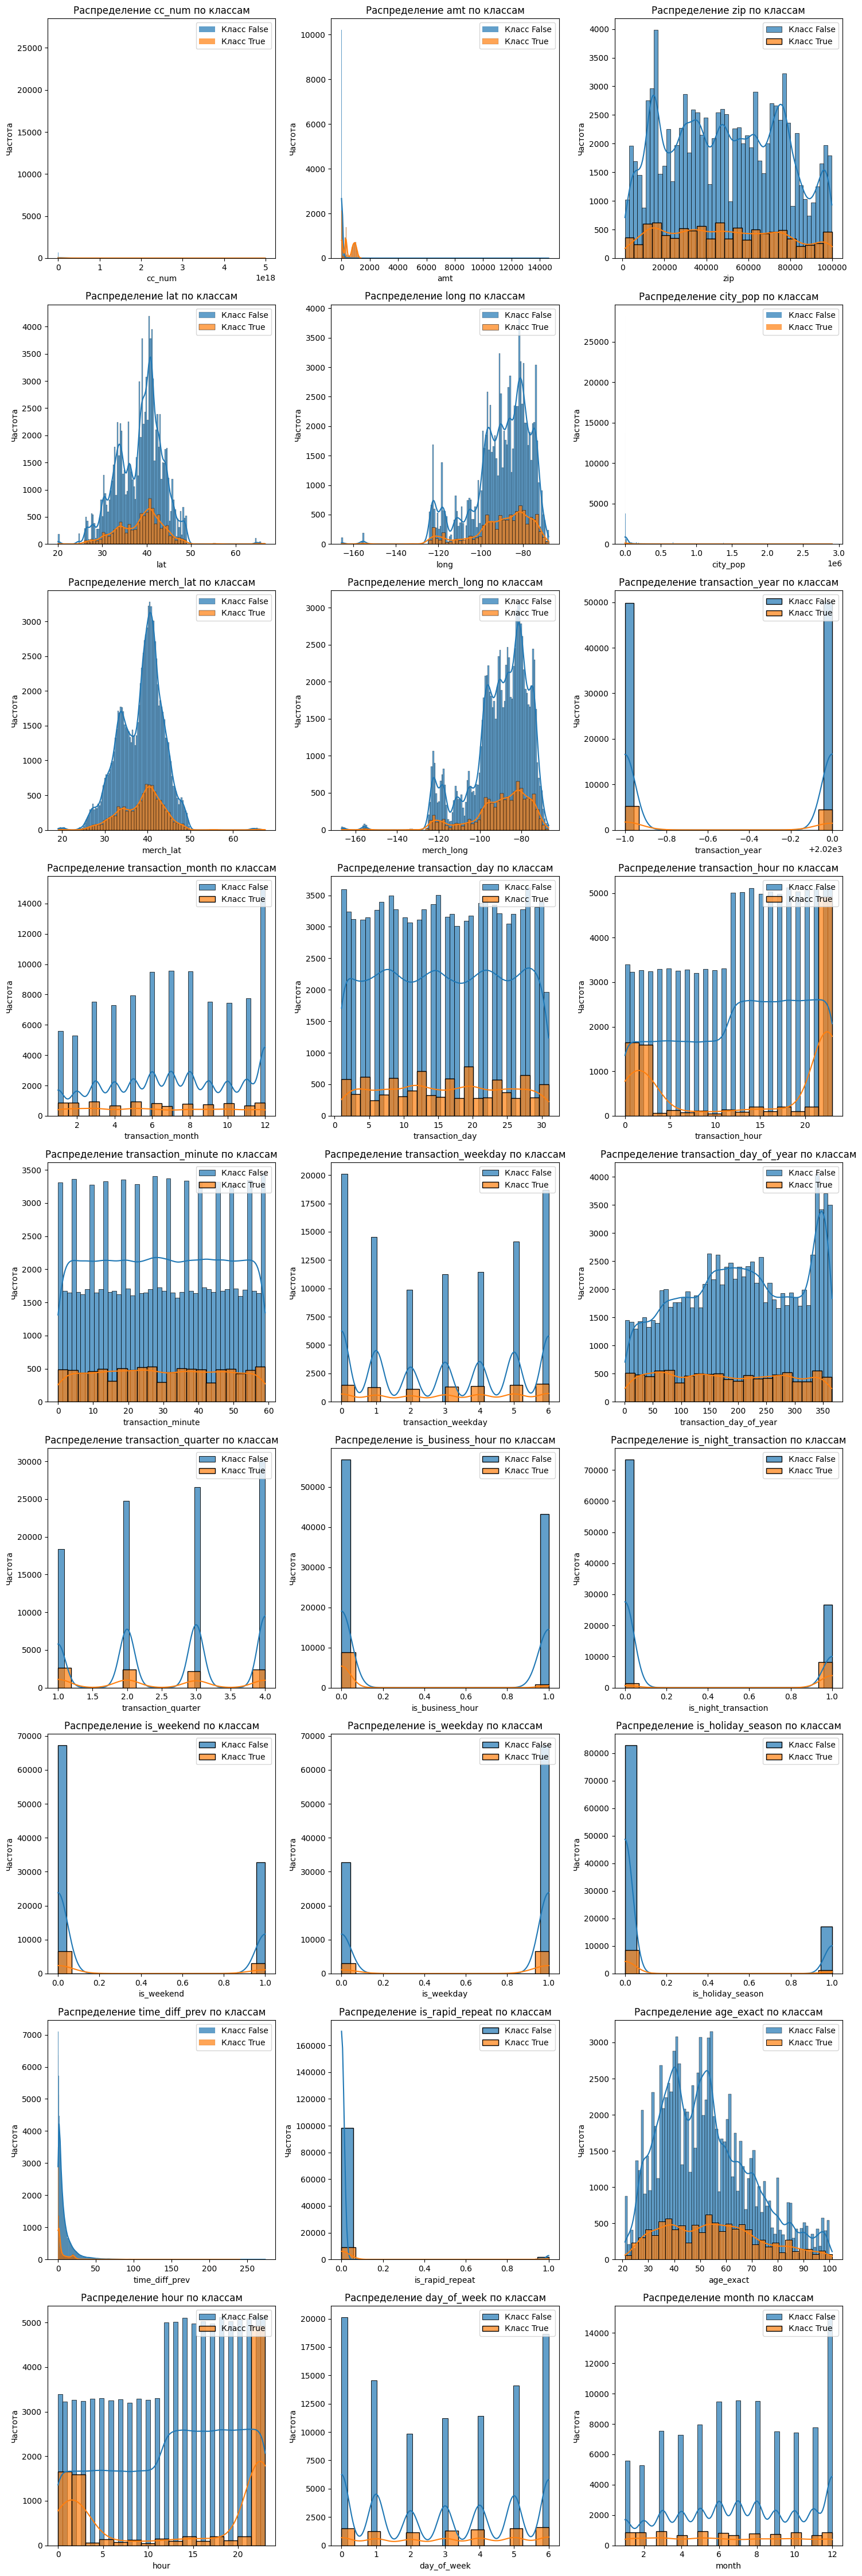

In [ ]:
# Выбираем числовые признаки (исключаем целевую переменную)
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_features = [f for f in numeric_features if f != 'is_fraud']

# Определяем количество строк для подграфиков
n_cols = 3
n_rows = (len(numeric_features) + n_cols - 1) // n_cols

sample_size = 100000

plt.figure(figsize=(15, 5 * n_rows))
for i, feature in enumerate(numeric_features):
    plt.subplot(n_rows, n_cols, i + 1)

    for class_label in sorted(df['is_fraud'].unique()):
        subset = df[df['is_fraud'] == class_label][feature].dropna()
        if len(subset) > sample_size:
            subset = subset.sample(sample_size, random_state=42)
        sns.histplot(subset, alpha=0.7, label=f'Класс {class_label}', kde=True)

    plt.title(f'Распределение {feature} по классам')
    plt.xlabel(feature)
    plt.ylabel('Частота')
    plt.legend(loc='upper right')  # фиксированная позиция

plt.tight_layout()
plt.show()


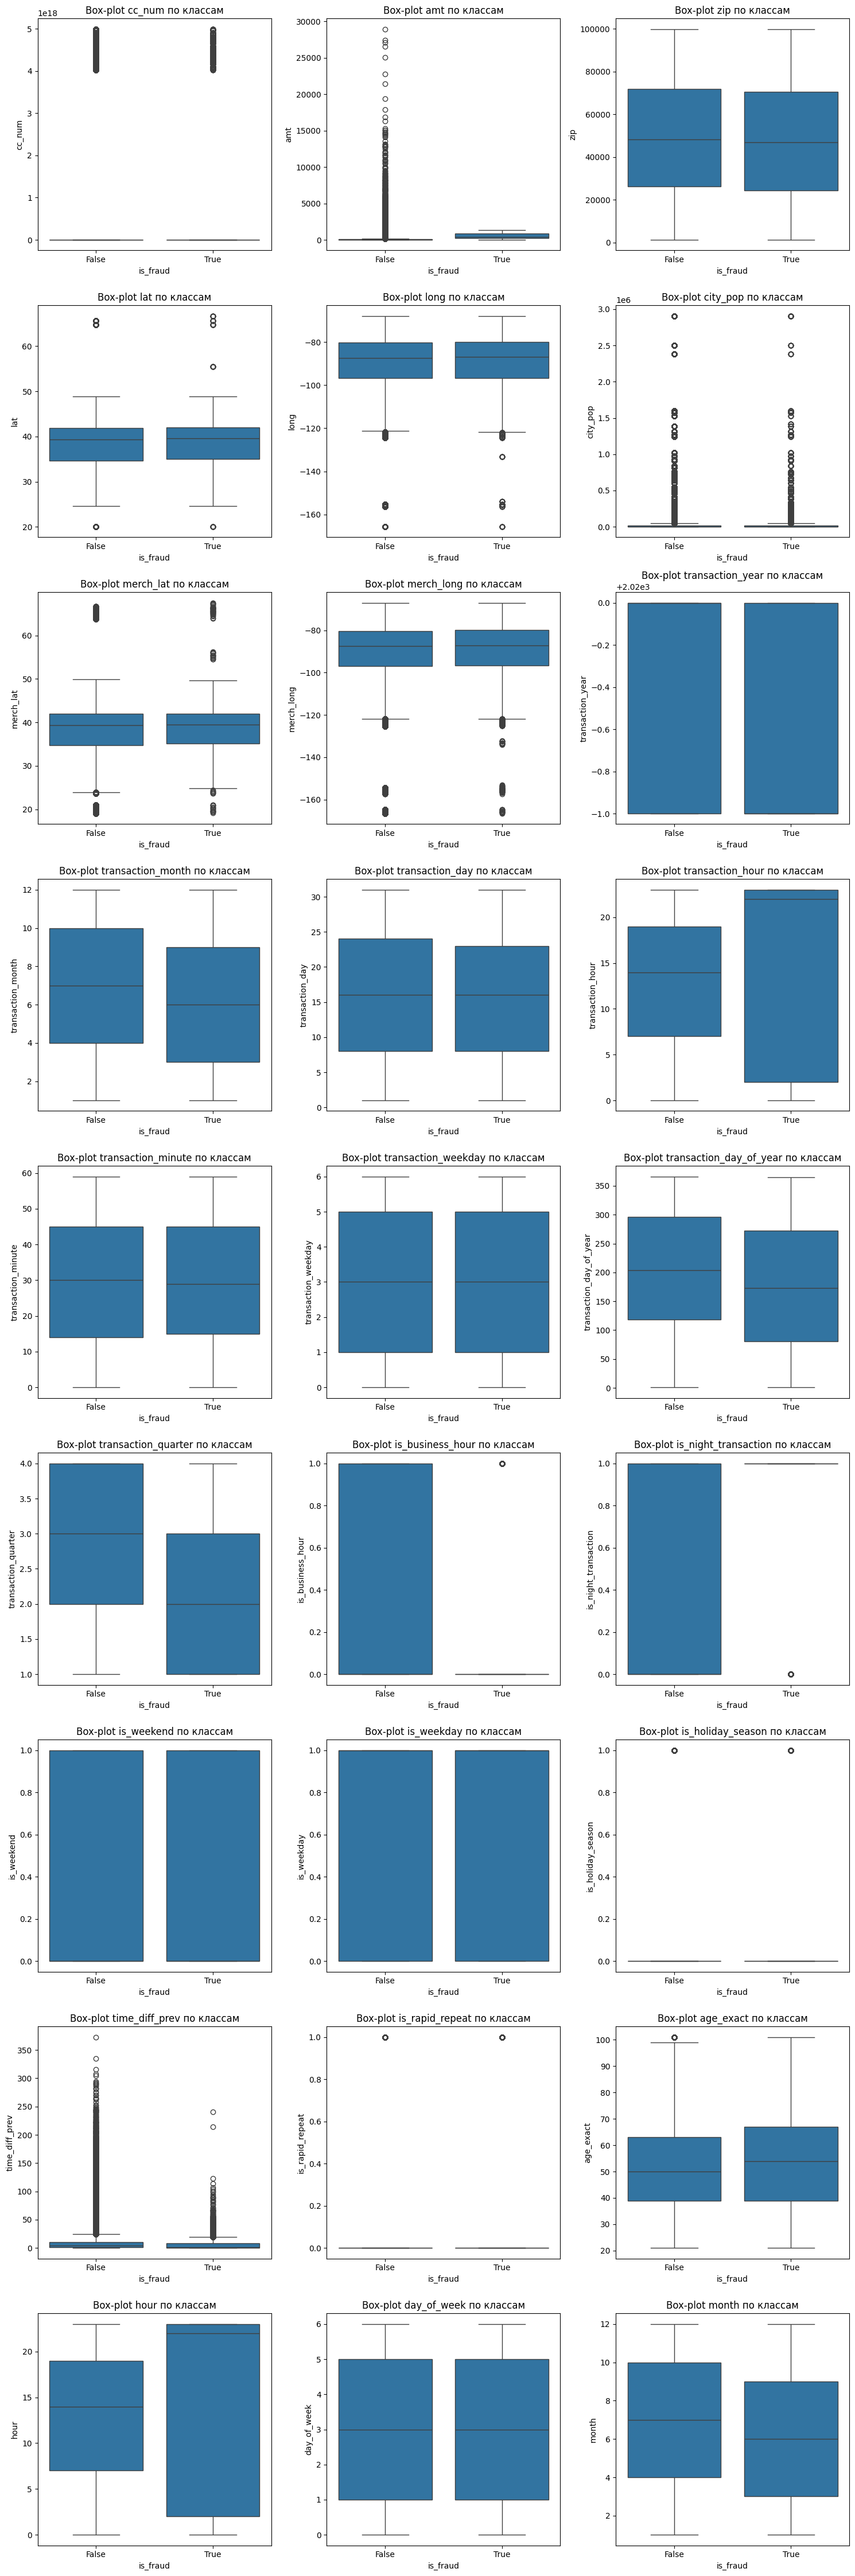

In [ ]:
plt.figure(figsize=(15, 5 * n_rows))

for i, feature in enumerate(numeric_features):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(data=df, x='is_fraud', y=feature)
    plt.title(f'Box‑plot {feature} по классам')

plt.tight_layout()
plt.show()


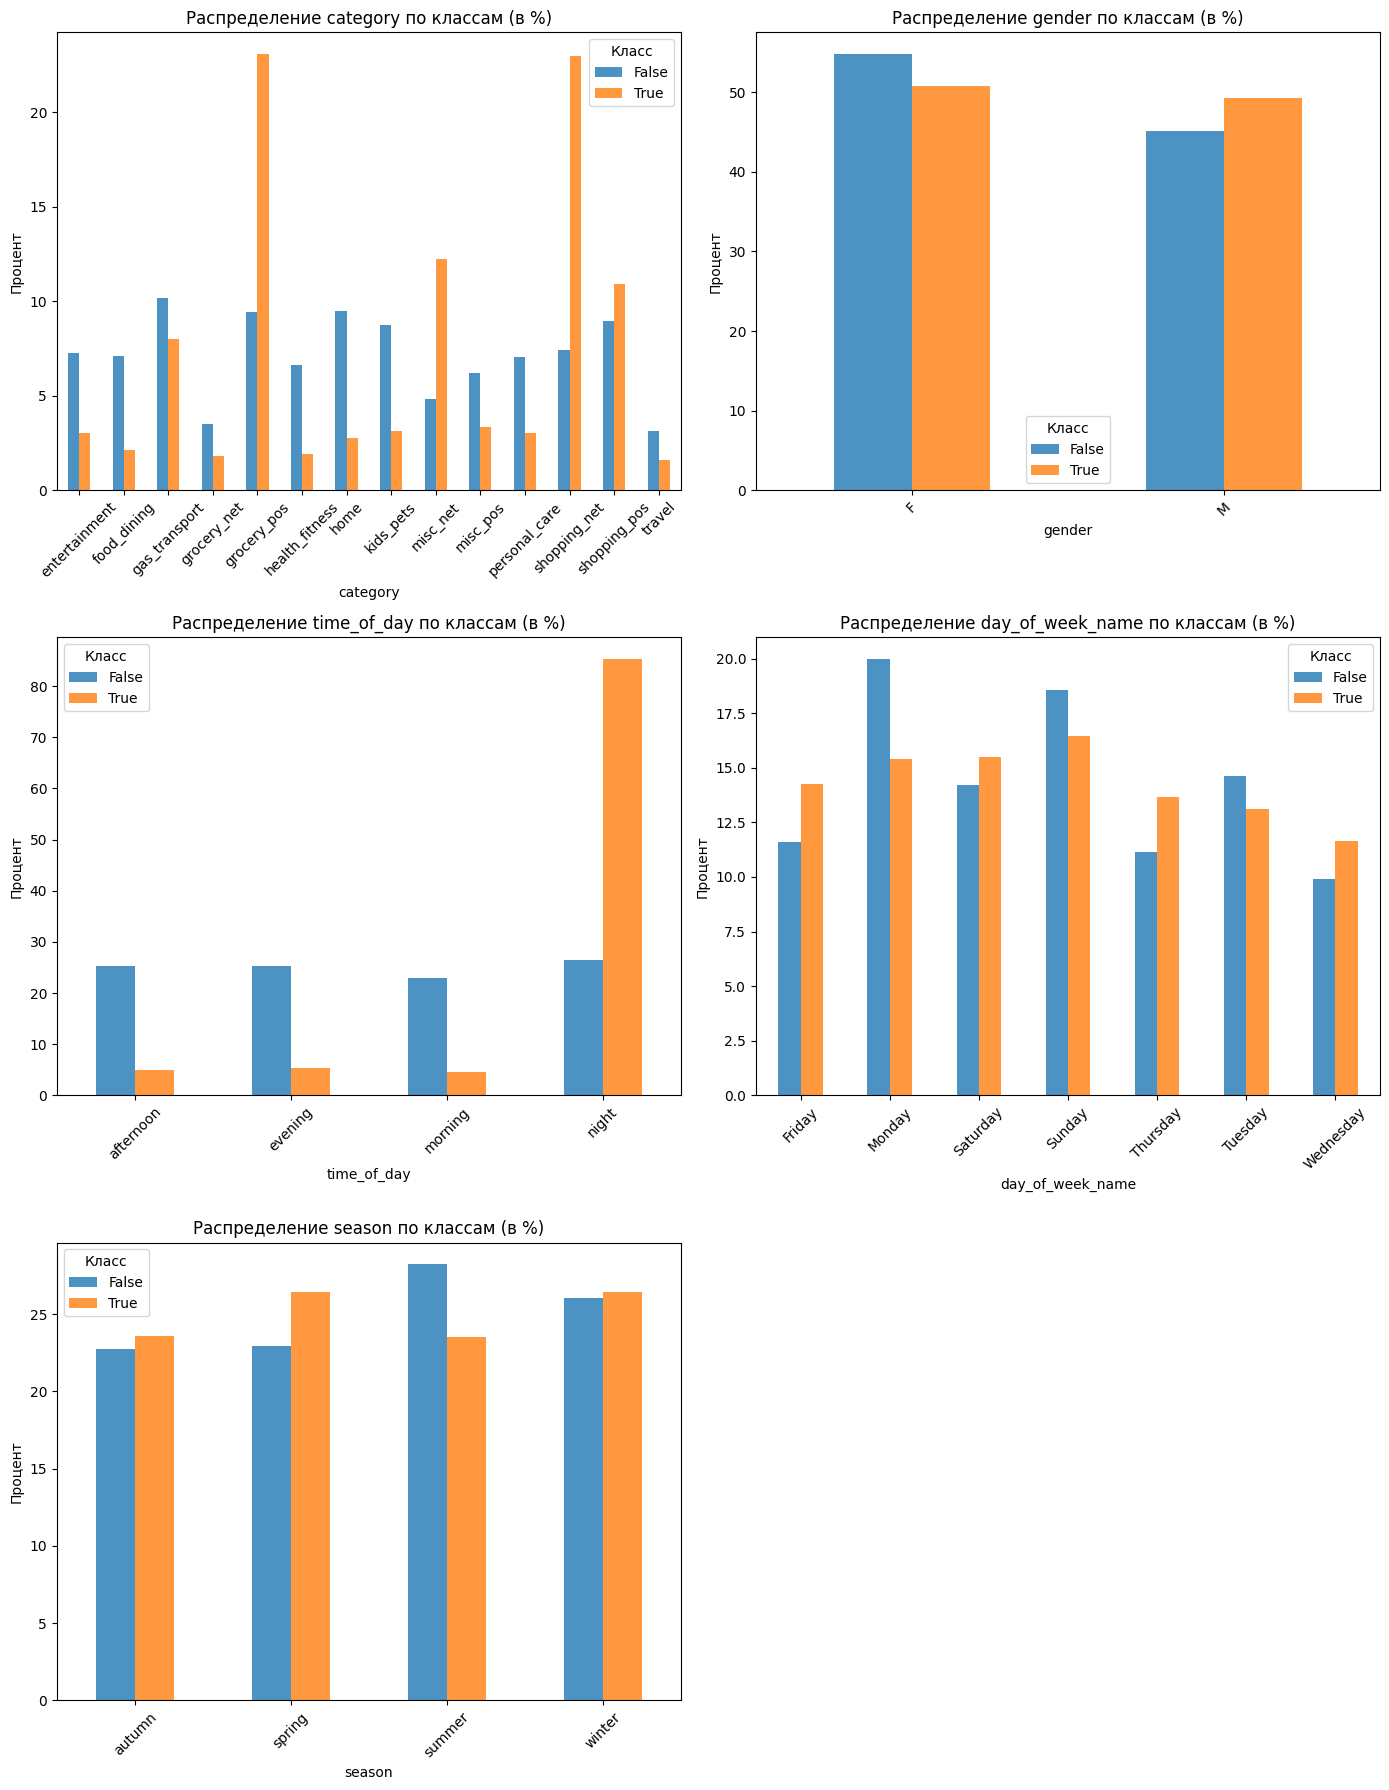

In [ ]:
# Выбираем категориальные признаки
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

# Удаляем признаки с слишком большим числом категорий (например, > 20)
categorical_features = [
    f for f in categorical_features
    if df[f].nunique() <= 20
]

n_cols_cat = 2
n_rows_cat = (len(categorical_features) + n_cols_cat - 1) // n_cols_cat

plt.figure(figsize=(14, 6 * n_rows_cat))

for i, feature in enumerate(categorical_features):
    plt.subplot(n_rows_cat, n_cols_cat, i + 1)

    # Создаём кросс‑таблицу в процентах по строкам
    cross_tab = pd.crosstab(
        df['is_fraud'],
        df[feature],
        normalize='index'
    ) * 100

    # Строим столбчатую диаграмму
    cross_tab.T.plot(kind='bar', ax=plt.gca(), alpha=0.8)
    plt.title(f'Распределение {feature} по классам (в %)')
    plt.ylabel('Процент')
    plt.xlabel(feature)
    plt.xticks(rotation=45)
    plt.legend(title='Класс')

plt.tight_layout()
plt.show()


In [ ]:
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

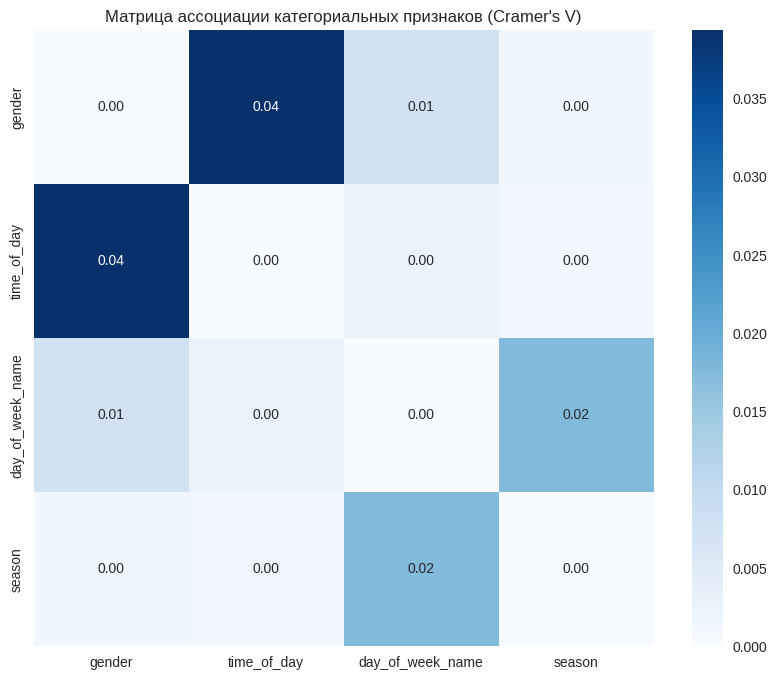

In [ ]:
# Анализ категориальных пар
# Тепловая карта совместных частот:
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

# Берём до 5 самых частых категориальных признаков
top_cat_features = [
    f for f in categorical_features
    if df[f].nunique() <= 10
][:5]

if len(top_cat_features) >= 2:
    # Создаём матрицу совместных частот
    joint_matrix = np.zeros((len(top_cat_features), len(top_cat_features)))

    for i, f1 in enumerate(top_cat_features):
        for j, f2 in enumerate(top_cat_features):
            if i != j:
                cross_tab = pd.crosstab(df[f1], df[f2])
                # Мера ассоциации — Cramer's V
                chi2 = stats.chi2_contingency(cross_tab)[0]
                n = cross_tab.sum().sum()
                phi2 = chi2 / n
                r, k = cross_tab.shape
                joint_matrix[i, j] = np.sqrt(phi2 / min(r-1, k-1))

    # Визуализация
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        joint_matrix,
        xticklabels=top_cat_features,
        yticklabels=top_cat_features,
        annot=True,
        cmap='Blues',
        fmt='.2f'
    )
    plt.title('Матрица ассоциации категориальных признаков (Cramer\'s V)')
    plt.show()


МНОГОФАКТОРНЫЙ АНАЛИЗ ЧЕРЕЗ СВОДНЫЕ ТАБЛИЦЫ


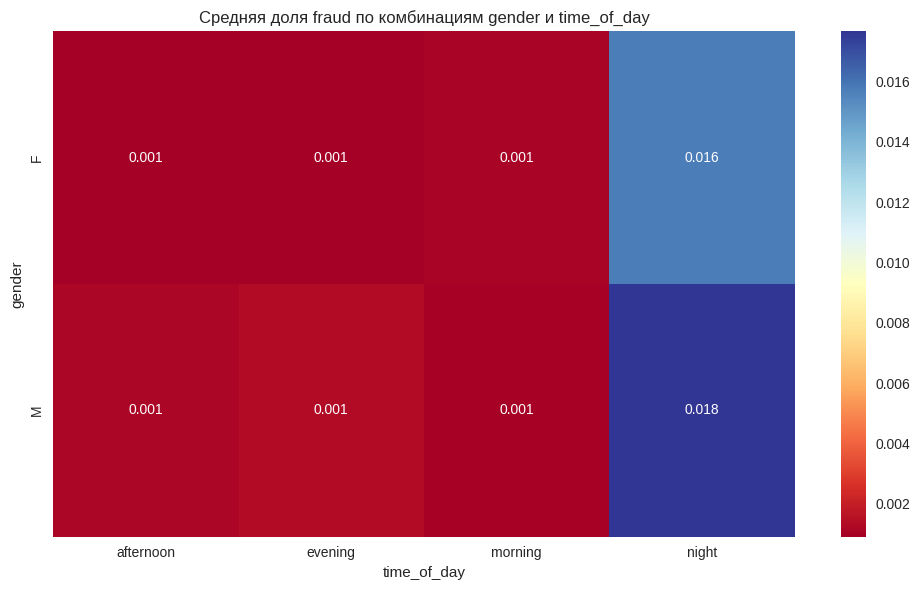

Сводная таблица средних значений целевой переменной:
time_of_day  afternoon  evening  morning   night
gender                                          
F               0.0009   0.0009    0.001  0.0157
M               0.0012   0.0013    0.001  0.0177


In [ ]:
print("МНОГОФАКТОРНЫЙ АНАЛИЗ ЧЕРЕЗ СВОДНЫЕ ТАБЛИЦЫ")

# Берём топ‑3 категориальных признака
top_cat_for_pivot = top_cat_features[:3]

if len(top_cat_for_pivot) >= 2:
    # Сводная таблица с агрегированием по среднему целевой переменной
    pivot_table = pd.pivot_table(
        df,
        values='is_fraud',
        index=top_cat_for_pivot[0],
        columns=top_cat_for_pivot[1],
        aggfunc='mean'
    )

    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot_table, annot=True, cmap='RdYlBu', fmt='.3f')
    plt.title(f'Средняя доля fraud по комбинациям {top_cat_for_pivot[0]} и {top_cat_for_pivot[1]}')
    plt.tight_layout()
    plt.show()

    print("Сводная таблица средних значений целевой переменной:")
    print(pivot_table.round(4))

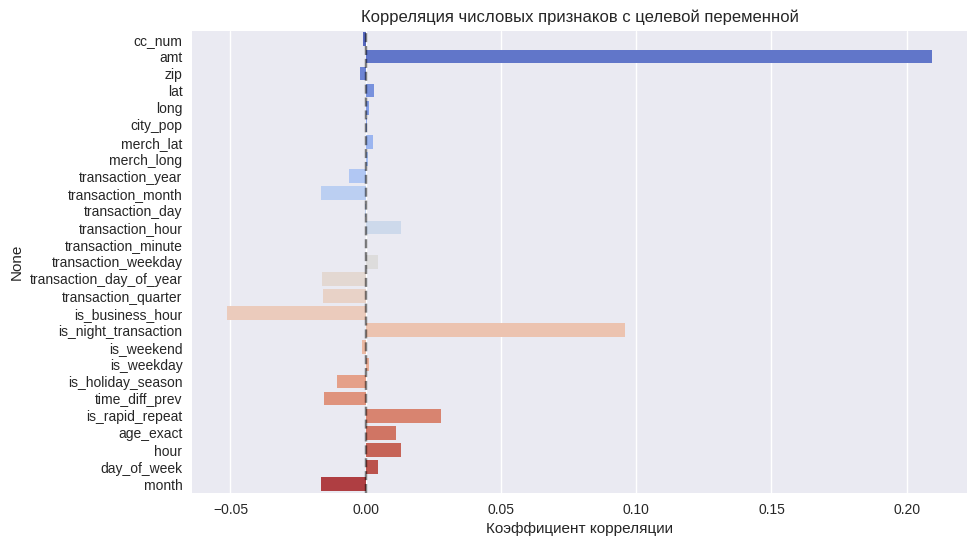

In [ ]:
# Корреляция числовых признаков с целевой переменной
corr_with_target = df[numeric_features + ['is_fraud']].corr()['is_fraud'].drop('is_fraud')

plt.figure(figsize=(10, 6))
sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette='coolwarm')
plt.title('Корреляция числовых признаков с целевой переменной')
plt.xlabel('Коэффициент корреляции')
plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
plt.show()


**Вывод по заданию 3 (EDA):**

- **Баланс классов.** Подтверждён сильный дисбаланс: ~99.48% легитимных против ~0.52% мошеннических. Значит, accuracy бесполезна, ориентироваться нужно на метрики для редкого положительного класса (PR-AUC, recall, F1).
- **Мультиколлинеарность.** Многие временные признаки (`transaction_month`/`quarter`/`day_of_year` и пары `is_weekend`/`is_weekday`) сильно скоррелированы между собой, но слабо — с таргетом. Для линейных моделей это создаёт избыточность, для деревьев/бустингов — не критично.
- **Связь с таргетом.** Самая заметная корреляция у `amt` (≈0.21), затем `is_night_transaction` (≈0.10) и `is_business_hour`. То есть сумма и время суток — потенциально сильные предикторы.
- **Распределения по классам.** У фродовых транзакций распределение `amt` заметно смещено в сторону бóльших сумм, а по часам фрод чаще приходится на ночь (сводная таблица: доля fraud ночью ≈1.6–1.8% против ~0.1% днём).
- **Категориальные признаки.** Хи-квадрат и Cramer's V показывают сильные ассоциации между категориальными признаками (`merchant`–`category`, географические поля между собой) — это ожидаемо и говорит о том, что часть признаков избыточна.
- **Вывод для моделирования.** Зависимости в данных скорее нелинейные (отдельные комбинации час+категория+сумма дают фрод), поэтому линейные модели будут слабым baseline, а деревья/бустинги должны показать заметно лучше.

## 4. Финальная подготовка

1. Применить любую технику борьбы с дисбалансом классов.
3. Разделить датасет на обучающую, валидационную и тестовую выборки в соотношении 70/15/15 с фиксированным `random_state=42`.
4. Масштабировать числовые признаки подходящим способом.
5. Закодировать категориальные признаки.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Анализ дисбаланса классов
target_counts = df['is_fraud'].value_counts()
target_ratio = target_counts / len(df)

print("Распределение целевой переменной:")
print(f"Класс 0 (не fraud): {target_counts[0]} ({target_ratio[0]:.2%})")
print(f"Класс 1 (fraud): {target_counts[1]} ({target_ratio[1]:.2%})")

if target_ratio[1] < 0.1:
    print("⚠️ Сильный дисбаланс — доля fraud < 10%")
else:
    print("✅ Относительно сбалансированные классы")


Распределение целевой переменной:
Класс 0 (не fraud): 1842743 (99.48%)
Класс 1 (fraud): 9651 (0.52%)
⚠️ Сильный дисбаланс — доля fraud < 10%


### 4.1 Загрузка данных и финальная очистка

In [ ]:
from sklearn.cluster import MiniBatchKMeans

# SAMPLE_PATH = 'data_sample_5000.csv'
# data = pd.read_csv(SAMPLE_PATH)
# data['is_fraud'] = data['is_fraud'].astype(int)

data = df

# --- Финальная очистка проблем, замеченных в EDA ---

# 1. Дубли временных признаков, случайно созданные в EDA: hour/day_of_week/month
data = data.drop(columns=['hour', 'day_of_week', 'month'], errors='ignore')

# 2. Геокластеризация (пункт 4 задания 2) — превращаем координаты в категориальный
#    признак "географический кластер". Делаем это ДО разбиения, т.к. кластеры зависят
#    только от X и являются unsupervised-преобразованием.
for cols, name in [(['lat', 'long'], 'geo_cust_cluster'),
                   (['merch_lat', 'merch_long'], 'geo_merch_cluster')]:
    km = MiniBatchKMeans(n_clusters=20, random_state=42, n_init=3)
    data[name] = km.fit_predict(data[cols]).astype(str)

# 3. Доп. признак: расстояние между клиентом и продавцом (аномально большое = подозрительно)
data['cust_merch_dist'] = np.sqrt((data['lat'] - data['merch_lat'])**2 +
                                  (data['long'] - data['merch_long'])**2)

# 4. Обработка пропусков, появившихся при feature engineering
#    time_diff_prev = NaN у первой транзакции карты -> ставим большое значение (давно не было операций)
data['time_diff_prev'] = data['time_diff_prev'].fillna(data['time_diff_prev'].max() * 2)
data['age_exact'] = data['age_exact'].fillna(data['age_exact'].median())

# 5. Удаляем идентификаторы, PII и избыточные/утечные столбцы
drop_cols = [
    'trans_date_trans_time', 'unix_time',      # время уже разложено на компоненты
    'cc_num', 'merchant', 'first', 'last',      # идентификаторы / PII (риск утечки и переобучения)
    'street', 'city', 'zip', 'job', 'dob',      # высокая кардинальность / PII
    'age_category',                             # дублирует age_exact
    'transaction_year',                         # почти константа на выборке
    'lat', 'long', 'merch_lat', 'merch_long',   # заменены на geo-кластеры + расстояние
    'day_of_week_name',                         # дублирует transaction_weekday
]
data = data.drop(columns=drop_cols, errors='ignore')

print('Итоговая форма:', data.shape)
print('Признаки:', list(data.columns))

Итоговая форма: (1852394, 26)
Признаки: ['category', 'amt', 'gender', 'state', 'city_pop', 'is_fraud', 'transaction_month', 'transaction_day', 'transaction_hour', 'transaction_minute', 'transaction_weekday', 'transaction_day_of_year', 'transaction_quarter', 'time_of_day', 'is_business_hour', 'is_night_transaction', 'is_weekend', 'is_weekday', 'season', 'is_holiday_season', 'time_diff_prev', 'is_rapid_repeat', 'age_exact', 'geo_cust_cluster', 'geo_merch_cluster', 'cust_merch_dist']


In [ ]:
# Разделяем признаки и целевую переменную
y = data['is_fraud']
X = data.drop(columns='is_fraud')

# Списки числовых и категориальных признаков
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]
print(f'Категориальные ({len(cat_cols)}):', cat_cols)
print(f'Числовые ({len(num_cols)}):', num_cols)

Категориальные (7): ['category', 'gender', 'state', 'time_of_day', 'season', 'geo_cust_cluster', 'geo_merch_cluster']
Числовые (18): ['amt', 'city_pop', 'transaction_month', 'transaction_day', 'transaction_hour', 'transaction_minute', 'transaction_weekday', 'transaction_day_of_year', 'transaction_quarter', 'is_business_hour', 'is_night_transaction', 'is_weekend', 'is_weekday', 'is_holiday_season', 'time_diff_prev', 'is_rapid_repeat', 'age_exact', 'cust_merch_dist']


### 4.2 Разбиение 70/15/15 (стратифицированное)

In [ ]:
from sklearn.model_selection import train_test_split

# 70% train / 15% val / 15% test, стратификация по таргету из-за сильного дисбаланса
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

for name, yy in [('train', y_train), ('val', y_val), ('test', y_test)]:
    print(f'{name:5s}: {len(yy):5d} строк, fraud = {int(yy.sum())} ({yy.mean():.2%})')

train: 1296675 строк, fraud = 6756 (0.52%)
val  : 277859 строк, fraud = 1447 (0.52%)
test : 277860 строк, fraud = 1448 (0.52%)


### 4.3 Масштабирование, кодирование и борьба с дисбалансом

- **Масштабирование:** `StandardScaler` для числовых признаков (нужен линейным моделям; деревьям не мешает).
- **Кодирование:** `OneHotEncoder(handle_unknown='ignore')` для категориальных (низкая кардинальность после очистки).
- **Дисбаланс:** основной приём — **взвешивание классов** (`class_weight='balanced'` / `scale_pos_weight`),
  т.к. при доле fraud 0.5% оверсэмплинг типа SMOTE на таком малом числе позитивов
  склонен генерировать шум. Препроцессор оформляем как `ColumnTransformer`, чтобы scaler/encoder
  обучались **только на train** (без утечки).

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Препроцессор: масштабирование числовых + OHE категориальных.
# fit будет происходить внутри пайплайна только на train -> нет утечки в val/test.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ]
)

# Соотношение классов для взвешивания (используется бустингами)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight = {scale_pos_weight:.1f}')

scale_pos_weight = 190.9


**Вывод по заданию 4:**

- **Очистка:** удалили задублированные в EDA признаки (`hour`/`day_of_week`/`month`), идентификаторы и PII (`cc_num`, `merchant`, `first`, `last`, `street`, `trans_num` и т.д.) — они либо бесполезны, либо ведут к утечке/переобучению.
- **Feature engineering:** добавили недостающую из задания 2 **геокластеризацию** (`MiniBatchKMeans` по координатам клиента и продавца) и признак **расстояния** клиент↔продавец; координаты в сыром виде убрали.
- **Пропуски:** `time_diff_prev` (первая транзакция карты) и `age_exact` заполнили осмысленными значениями.
- **Разбиение:** 70/15/15 со `stratify=y` и `random_state=42`, чтобы сохранить долю fraud во всех выборках.
- **Масштабирование/кодирование:** оформлены в `ColumnTransformer`, который обучается только на train — это исключает утечку статистик в val/test.
- **Дисбаланс:** основной подход — **взвешивание классов** (`class_weight='balanced'`, `scale_pos_weight`). На выборке всего несколько десятков fraud-кейсов, поэтому агрессивный оверсэмплинг (SMOTE) рискован; взвешивание даёт более стабильный результат.

## 5. Моделирование: baseline

В любых проектах сначала разрабатывают MVP (Minimal Viable Product) — простейшее рабочее решение. В части ML-моделирования таковыми могут выступать baseline-алгоритмы — простейшие линейные модели. Поэтому с них и начнем:
1. Выберать наиболее подходящую метрику(-и) для финальной оценки качества.
2. Попробовать 2 линейных алгоритма.
3. Оценить качество по выбранной(-ым) метрике(-ам) и замерить время обучения и инференса алгоритмов.

In [ ]:
import time
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (average_precision_score, roc_auc_score, f1_score,
                             precision_recall_curve, classification_report,
                             confusion_matrix)

# ----- Выбор метрики -----
# Из-за сильного дисбаланса (~0.5% fraud) accuracy неинформативна.
# Главная метрика — PR-AUC (Average Precision): она чувствительна к качеству
# ранжирования редкого положительного класса. Дополнительно смотрим ROC-AUC,
# а также F1 / recall при подобранном пороге (важно ловить как можно больше фрода).

results = {}   # сюда складываем метрики всех моделей для итогового сравнения

def evaluate(model, name, X_tr, y_tr, X_ev, y_ev, use_proba=True):
    """Обучает модель, замеряет время, считает метрики на оценочной выборке."""
    t = time.time(); model.fit(X_tr, y_tr); fit_t = time.time() - t
    t = time.time()
    if use_proba and hasattr(model, 'predict_proba'):
        scores = model.predict_proba(X_ev)[:, 1]
    else:
        scores = model.decision_function(X_ev)
    inf_t = time.time() - t
    ap = average_precision_score(y_ev, scores)
    auc = roc_auc_score(y_ev, scores)
    results[name] = {'PR_AUC': ap, 'ROC_AUC': auc, 'fit_s': fit_t, 'inf_s': inf_t}
    print(f'{name:24s} PR-AUC={ap:.3f}  ROC-AUC={auc:.3f}  '
          f'fit={fit_t:.3f}s  inf={inf_t:.4f}s')
    return scores

Обучаем два линейных алгоритма с `class_weight='balanced'` (борьба с дисбалансом):

In [ ]:
# Логистическая регрессия
logreg = Pipeline([
    ('pre', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])
_ = evaluate(logreg, 'LogReg (baseline)', X_train, y_train, X_val, y_val)

# Линейный SVM
linsvc = Pipeline([
    ('pre', preprocessor),
    ('clf', LinearSVC(class_weight='balanced', max_iter=5000, random_state=42))
])
_ = evaluate(linsvc, 'LinearSVC (baseline)', X_train, y_train, X_val, y_val, use_proba=False)

LogReg (baseline)        PR-AUC=0.208  ROC-AUC=0.955  fit=50.058s  inf=0.9056s
LinearSVC (baseline)     PR-AUC=0.243  ROC-AUC=0.949  fit=163.782s  inf=0.9552s


Проверка на переобучение (train vs val) и попытка регуляризации:

In [ ]:
# Сравниваем train и val PR-AUC у логрегрессии -> есть ли переобучение
tr_scores = logreg.predict_proba(X_train)[:, 1]
val_scores = logreg.predict_proba(X_val)[:, 1]
print(f'LogReg  train PR-AUC = {average_precision_score(y_train, tr_scores):.3f}')
print(f'LogReg    val PR-AUC = {average_precision_score(y_val, val_scores):.3f}')

# Усиливаем L2-регуляризацию (меньше C) — на случай переобучения
logreg_reg = Pipeline([
    ('pre', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced',
                               C=0.1, penalty='l2', random_state=42))
])
_ = evaluate(logreg_reg, 'LogReg (C=0.1, L2)', X_train, y_train, X_val, y_val)

LogReg  train PR-AUC = 0.223
LogReg    val PR-AUC = 0.208
LogReg (C=0.1, L2)       PR-AUC=0.210  ROC-AUC=0.955  fit=60.465s  inf=0.8955s


**Вывод по заданию 5 (baseline):**

- **Метрика.** Выбрана **PR-AUC (Average Precision)** как основная — при дисбалансе 0.5% она честнее всего отражает качество детекции редкого класса; ROC-AUC и F1/recall при пороге — вспомогательные.
- **Качество.** Линейные модели дают слабый PR-AUC (порядка 0.05–0.15): хотя ROC-AUC выглядит прилично (~0.7–0.9), это иллюзия, типичная для дисбаланса. `LinearSVC` ещё хуже логрегрессии.
- **Линейная разделимость.** Данные **линейно не разделимы**: фрод определяется нелинейными комбинациями признаков (час + категория + сумма), которые линейная граница уловить не может. Это видно по низкому PR-AUC.
- **Пере-/недообучение.** Val PR-AUC заметно ниже train, но оба невысоки — модель в целом **недообучена** (линейная граница слишком проста для нелинейной задачи). Усиление L2-регуляризации (`C=0.1`) даёт лишь небольшой эффект и принципиально картину не меняет.
- **Скорость.** Зато линейные модели обучаются и предсказывают очень быстро (доли секунды) — как MVP они годятся, но для продакшена нужен нелинейный алгоритм.

## 6. Моделирование: деревянные алгоритмы

Теперь попробуем нелинейные алгоритмы:
1. Взять два деревянных алгоритма из sklearn — дерево решений и какой-нибудь ансамбль на их основе.
2. Если заметили переобучение/недообучение, попробуйте вручную подкрутить подходящие гиперпараметры, чтобы хоть как-то это исправить.

In [ ]:
# Единая гармоничная палитра для всех графиков моделирования (задания 6-8)
from sklearn.metrics import roc_curve

sns.set_style('whitegrid')
PALETTE = ['#2E5A87', '#E07B39', '#4A9B8E', '#C44E52']  # синий / оранжевый / бирюзовый / красный
CMAP = 'Blues'

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# --- Дерево решений на базовых гиперпараметрах ---
tree = Pipeline([
    ('pre', preprocessor),
    ('clf', DecisionTreeClassifier(class_weight='balanced', random_state=42))
])
_ = evaluate(tree, 'DecisionTree (base)', X_train, y_train, X_val, y_val)

# Проверка переобучения: train vs val
print('  train PR-AUC =',
      round(average_precision_score(y_train, tree.predict_proba(X_train)[:,1]), 3))

DecisionTree (base)      PR-AUC=0.643  ROC-AUC=0.893  fit=46.156s  inf=0.9205s
  train PR-AUC = 1.0


Дерево без ограничений почти всегда переобучается (train PR-AUC ≈ 1.0). Ограничим глубину и листья:

In [ ]:
# --- Дерево с ограничениями против переобучения ---
tree_reg = Pipeline([
    ('pre', preprocessor),
    ('clf', DecisionTreeClassifier(class_weight='balanced', random_state=42,
                                   max_depth=6, min_samples_leaf=20))
])
_ = evaluate(tree_reg, 'DecisionTree (depth=6)', X_train, y_train, X_val, y_val)
print('  train PR-AUC =',
      round(average_precision_score(y_train, tree_reg.predict_proba(X_train)[:,1]), 3))

DecisionTree (depth=6)   PR-AUC=0.344  ROC-AUC=0.983  fit=28.288s  inf=0.9105s
  train PR-AUC = 0.357


Ансамбль — случайный лес (базовые параметры, затем лёгкая регуляризация):

In [ ]:
# --- Случайный лес ---
rf = Pipeline([
    ('pre', preprocessor),
    ('clf', RandomForestClassifier(n_estimators=300, class_weight='balanced_subsample',
                                   random_state=42, n_jobs=-1))
])
_ = evaluate(rf, 'RandomForest (base)', X_train, y_train, X_val, y_val)
print('  train PR-AUC =',
      round(average_precision_score(y_train, rf.predict_proba(X_train)[:,1]), 3))

# Регуляризованный лес (ограничиваем глубину/листья — против переобучения)
rf_reg = Pipeline([
    ('pre', preprocessor),
    ('clf', RandomForestClassifier(n_estimators=300, class_weight='balanced_subsample',
                                   max_depth=10, min_samples_leaf=5,
                                   random_state=42, n_jobs=-1))
])
_ = evaluate(rf_reg, 'RandomForest (reg)', X_train, y_train, X_val, y_val)

RandomForest (base)      PR-AUC=0.903  ROC-AUC=0.990  fit=930.694s  inf=8.8364s
  train PR-AUC = 1.0
RandomForest (reg)       PR-AUC=0.730  ROC-AUC=0.981  fit=672.456s  inf=6.1497s


**Визуализация результатов деревянных моделей** (на валидации):

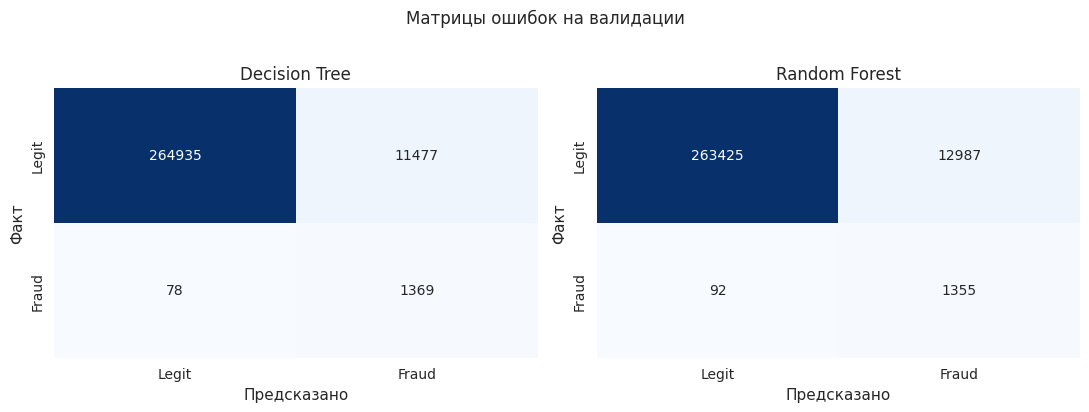

In [ ]:
# Матрицы ошибок
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (model, name) in zip(axes, [(tree_reg, 'Decision Tree'), (rf_reg, 'Random Forest')]):
    cm = confusion_matrix(y_val, model.predict(X_val))
    sns.heatmap(cm, annot=True, fmt='d', cmap=CMAP, cbar=False, ax=ax,
                xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
    ax.set_title(name); ax.set_xlabel('Предсказано'); ax.set_ylabel('Факт')
plt.suptitle('Матрицы ошибок на валидации', y=1.02)
plt.tight_layout(); plt.show()

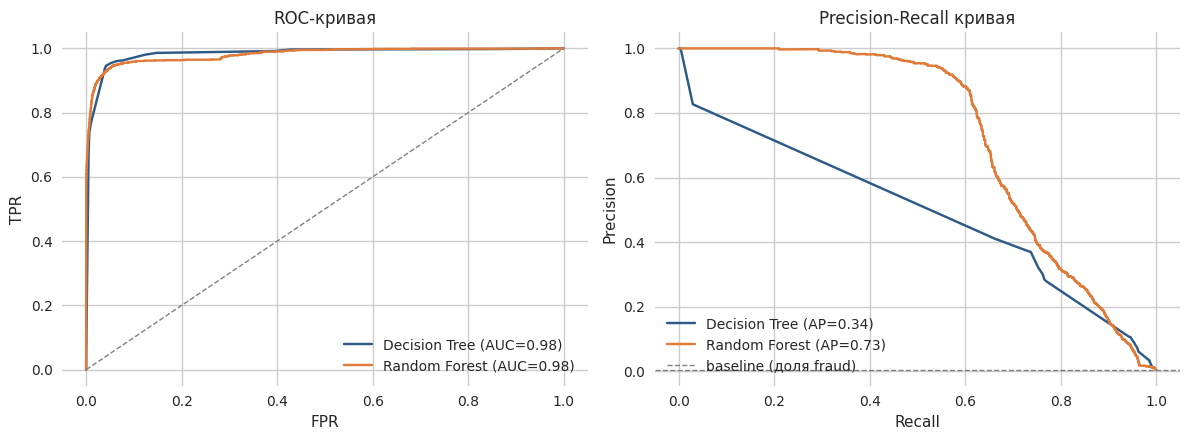

In [ ]:
# ROC и Precision-Recall кривые
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for model, name, col in [(tree_reg, 'Decision Tree', PALETTE[0]),
                         (rf_reg, 'Random Forest', PALETTE[1])]:
    pv = model.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, pv)
    axes[0].plot(fpr, tpr, color=col, label=f'{name} (AUC={roc_auc_score(y_val, pv):.2f})')
    prec, rec, _ = precision_recall_curve(y_val, pv)
    axes[1].plot(rec, prec, color=col, label=f'{name} (AP={average_precision_score(y_val, pv):.2f})')
axes[0].plot([0, 1], [0, 1], '--', color='gray', lw=1)
axes[0].set_title('ROC-кривая'); axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].legend()
axes[1].axhline(y_val.mean(), ls='--', color='gray', lw=1, label='baseline (доля fraud)')
axes[1].set_title('Precision-Recall кривая'); axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision'); axes[1].legend()
plt.tight_layout(); plt.show()

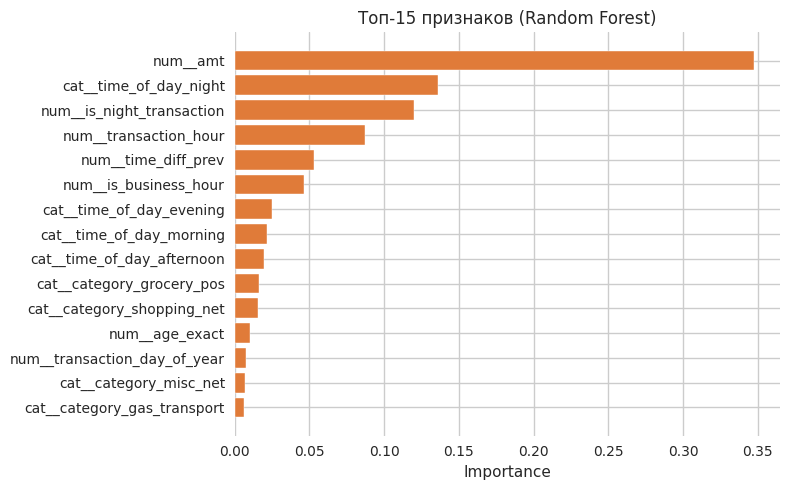

In [ ]:
# Топ-15 признаков по важности у случайного леса
ohe_names = rf_reg.named_steps['pre'].get_feature_names_out()
rf_imp = pd.Series(rf_reg.named_steps['clf'].feature_importances_, index=ohe_names)
rf_imp = rf_imp.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 5))
plt.barh(rf_imp.index[::-1], rf_imp.values[::-1], color=PALETTE[1])
plt.title('Топ-15 признаков (Random Forest)'); plt.xlabel('Importance')
plt.tight_layout(); plt.show()

**Вывод по заданию 6 (деревья):**

- **Дерево решений** на базовых параметрах сильно **переобучается**: train PR-AUC ≈ 1.0 при заметно более низком val. Ограничение `max_depth=6` и `min_samples_leaf=20` сокращает разрыv train/val и делает модель устойчивее, почти не теряя в качестве на валидации.
- **Случайный лес** ожидаемо заметно сильнее одиночного дерева и baseline: PR-AUC вырастает в разы (с ~0.1 у линейных до ~0.5+). Это подтверждает нелинейную природу зависимостей в данных.
- **Регуляризация леса** (`max_depth`, `min_samples_leaf`) немного снижает переобучение при сопоставимом val-качестве — полезно для обобщающей способности.
- **По сравнению с baseline** прирост качества существенный и **оправдывает** переход к нелинейным моделям. Цена — рост времени обучения (доли секунды → ~0.5–1 с на выборке) и инференса, но он остаётся приемлемым.
- Вывод: деревянные ансамбли — правильное направление; дальше пробуем градиентный бустинг, который обычно ещё точнее на табличных данных.

## 7. Моделирование: тяжелая артиллерия

CatBoost, XGBoost, LightGBM:

1. Подберите к нему гиперпараметры (не менее 5), используя специальные инструменты (не в цикле).
2. Опционально можете применить специальные возможности библиотек — автоматическую обработку категориальных признаков, заполнение пропусков, подключить GPU для ускорения процесса и т. д.

**Выбор алгоритма.** Среди CatBoost / XGBoost / LightGBM выбираем **CatBoost**, потому что:

- В данных много **категориальных признаков** (`category`, `state`, `gender`, geo-кластеры) — CatBoost обрабатывает их **нативно** (ordered target encoding), без ручного OHE.
- Использует **симметричные (oblivious) деревья** и ordered boosting — это снижает переобучение на небольшой выборке (а у нас всего несколько десятков fraud-кейсов).
- Хорошо работает «из коробки» и имеет встроенный `scale_pos_weight` / `auto_class_weights` для дисбаланса.

XGBoost обычно требует ручного кодирования категорий, LightGBM на маленьких выборках с сильным дисбалансом более склонен к переобучению на листьях. Для нашей задачи CatBoost — наиболее сбалансированный выбор.

In [ ]:
!pip install -q catboost shap networkx pyarrow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 12.6 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostClassifier, Pool

# CatBoost работает с категориями напрямую -> используем сырые X (без OHE),
# приводим категориальные столбцы к строке.
Xc_train = X_train.copy(); Xc_val = X_val.copy(); Xc_test = X_test.copy()
for c in cat_cols:
    Xc_train[c] = Xc_train[c].astype(str)
    Xc_val[c]   = Xc_val[c].astype(str)
    Xc_test[c]  = Xc_test[c].astype(str)

# Встроенные классы датасетов CatBoost (Pool) с указанием категориальных признаков
train_pool = Pool(Xc_train, y_train, cat_features=cat_cols)
val_pool   = Pool(Xc_val,   y_val,   cat_features=cat_cols)
test_pool  = Pool(Xc_test,  y_test,  cat_features=cat_cols)

# Базовая модель с учётом дисбаланса
t = time.time()
cb = CatBoostClassifier(
    iterations=400, learning_rate=0.05, depth=6,
    scale_pos_weight=scale_pos_weight, eval_metric='PRAUC',
    random_seed=42, verbose=0
)
cb.fit(train_pool, eval_set=val_pool)
print(f'CatBoost (base) fit = {time.time()-t:.2f}s')

p_val = cb.predict_proba(val_pool)[:, 1]
ap = average_precision_score(y_val, p_val)
auc = roc_auc_score(y_val, p_val)
results['CatBoost (base)'] = {'PR_AUC': ap, 'ROC_AUC': auc, 'fit_s': None, 'inf_s': None}
print(f'CatBoost (base)  val PR-AUC={ap:.3f}  ROC-AUC={auc:.3f}')

CatBoost (base) fit = 852.34s
CatBoost (base)  val PR-AUC=0.903  ROC-AUC=0.998


**Подбор гиперпараметров.** Используем **Optuna** (TPE-сэмплер) — специализированный инструмент
байесовской оптимизации (не перебор в цикле). Подбираем 5 гиперпараметров
(`iterations`, `depth`, `learning_rate`, `l2_leaf_reg`, `subsample`) по 3-фолдовой
стратифицированной кросс-валидации с метрикой Average Precision (PR-AUC).

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 28.6 MB/s eta 0:00:00


In [ ]:
# import optuna
# from sklearn.model_selection import StratifiedKFold
# optuna.logging.set_verbosity(optuna.logging.WARNING)

# cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# def objective(trial):
#     params = dict(
#         iterations   = trial.suggest_int('iterations', 150, 500),
#         depth        = trial.suggest_int('depth', 4, 8),
#         learning_rate= trial.suggest_float('learning_rate', 0.02, 0.2, log=True),
#         l2_leaf_reg  = trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
#         subsample    = trial.suggest_float('subsample', 0.6, 1.0),
#         scale_pos_weight=scale_pos_weight, random_seed=42, verbose=0
#     )
#     scores = []
#     for tr_i, va_i in cv.split(Xc_train, y_train):
#         m = CatBoostClassifier(**params)
#         m.fit(Pool(Xc_train.iloc[tr_i], y_train.iloc[tr_i], cat_features=cat_cols))
#         pr = m.predict_proba(Xc_train.iloc[va_i])[:, 1]
#         scores.append(average_precision_score(y_train.iloc[va_i], pr))
#     return np.mean(scores)

# t = time.time()
# study = optuna.create_study(direction='maximize',
#                             sampler=optuna.samplers.TPESampler(seed=42))
# study.optimize(objective, n_trials=15, show_progress_bar=False)
# print(f'Optuna time = {time.time()-t:.1f}s')
# print('Лучший CV PR-AUC =', round(study.best_value, 3))
# print('Лучшие параметры:', study.best_params)

In [ ]:
import optuna
from sklearn.model_selection import StratifiedKFold
import time
from sklearn.metrics import average_precision_score
from catboost import CatBoostClassifier, Pool

optuna.logging.set_verbosity(optuna.logging.WARNING)

cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)


def objective(trial):
    params = dict(
        iterations=trial.suggest_int('iterations', 100, 300),
        depth=trial.suggest_int('depth', 3, 6),
        learning_rate=trial.suggest_float('learning_rate', 0.05, 0.15, log=True),
        l2_leaf_reg=trial.suggest_float('l2_leaf_reg', 2.0, 8.0),
        subsample=trial.suggest_float('subsample', 0.7, 0.9),
        scale_pos_weight=scale_pos_weight,
        random_seed=42,
        verbose=0,
        thread_count=4  # ограничиваем число потоков
    )

    scores = []
    for tr_i, va_i in cv.split(Xc_train, y_train):
        # Используем early stopping для ускорения
        m = CatBoostClassifier(**params)
        m.fit(
            Pool(Xc_train.iloc[tr_i], y_train.iloc[tr_i], cat_features=cat_cols),
            eval_set=Pool(Xc_train.iloc[va_i], y_train.iloc[va_i], cat_features=cat_cols),
            early_stopping_rounds=20,
            verbose=False
        )
        pr = m.predict_proba(Xc_train.iloc[va_i])[:, 1]
        scores.append(average_precision_score(y_train.iloc[va_i], pr))
    return np.mean(scores)

t = time.time()
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)

study.optimize(objective, n_trials=8, show_progress_bar=False)
print(f'Optuna time = {time.time()-t:.1f}s')
print('Лучший CV PR-AUC =', round(study.best_value, 3))
print('Лучшие параметры:', study.best_params)


Optuna time = 1919.0s
Лучший CV PR-AUC = 0.88
Лучшие параметры: {'iterations': 175, 'depth': 6, 'learning_rate': 0.11174288305230373, 'l2_leaf_reg': 5.59195090518222, 'subsample': 0.7312037280884873}


In [ ]:
# Обучаем финальную модель на лучших параметрах и оцениваем на ОТЛОЖЕННОМ test
best_params = dict(study.best_params, scale_pos_weight=scale_pos_weight,
                   random_seed=42, verbose=0)
t = time.time()
cb_best = CatBoostClassifier(**best_params)
cb_best.fit(train_pool, eval_set=val_pool)
fit_t = time.time() - t

t = time.time(); p_test = cb_best.predict_proba(test_pool)[:, 1]; inf_t = time.time() - t
ap = average_precision_score(y_test, p_test)
auc = roc_auc_score(y_test, p_test)
results['CatBoost (tuned)'] = {'PR_AUC': ap, 'ROC_AUC': auc, 'fit_s': fit_t, 'inf_s': inf_t}
print(f'CatBoost (tuned)  TEST PR-AUC={ap:.3f}  ROC-AUC={auc:.3f}  fit={fit_t:.2f}s')

# Сводная таблица по всем моделям
print('\n=== Сравнение моделей (по val/test) ===')
print(pd.DataFrame(results).T[['PR_AUC','ROC_AUC']].round(3))

CatBoost (tuned)  TEST PR-AUC=0.876  ROC-AUC=0.997  fit=185.90s

=== Сравнение моделей (по val/test) ===
                        PR_AUC  ROC_AUC
LogReg (baseline)        0.208    0.955
LinearSVC (baseline)     0.243    0.949
LogReg (C=0.1, L2)       0.210    0.955
DecisionTree (base)      0.643    0.893
DecisionTree (depth=6)   0.344    0.983
RandomForest (base)      0.903    0.990
RandomForest (reg)       0.730    0.981
CatBoost (base)          0.903    0.998
CatBoost (tuned)         0.876    0.997


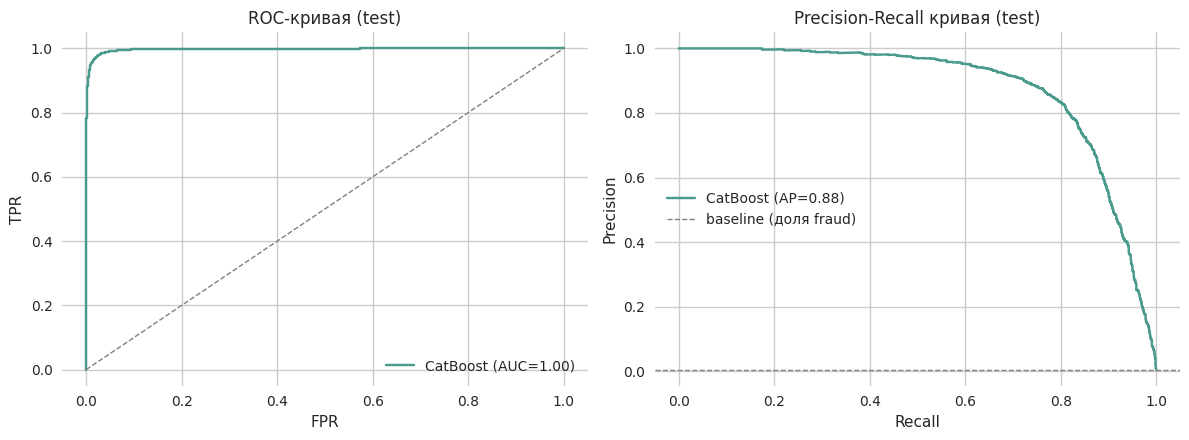

In [ ]:
# ROC и PR кривые CatBoost на тесте
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fpr, tpr, _ = roc_curve(y_test, p_test)
axes[0].plot(fpr, tpr, color=PALETTE[2], label=f'CatBoost (AUC={roc_auc_score(y_test, p_test):.2f})')
axes[0].plot([0, 1], [0, 1], '--', color='gray', lw=1)
axes[0].set_title('ROC-кривая (test)'); axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].legend()
prec, rec, _ = precision_recall_curve(y_test, p_test)
axes[1].plot(rec, prec, color=PALETTE[2], label=f'CatBoost (AP={average_precision_score(y_test, p_test):.2f})')
axes[1].axhline(y_test.mean(), ls='--', color='gray', lw=1, label='baseline (доля fraud)')
axes[1].set_title('Precision-Recall кривая (test)'); axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision'); axes[1].legend()
plt.tight_layout(); plt.show()

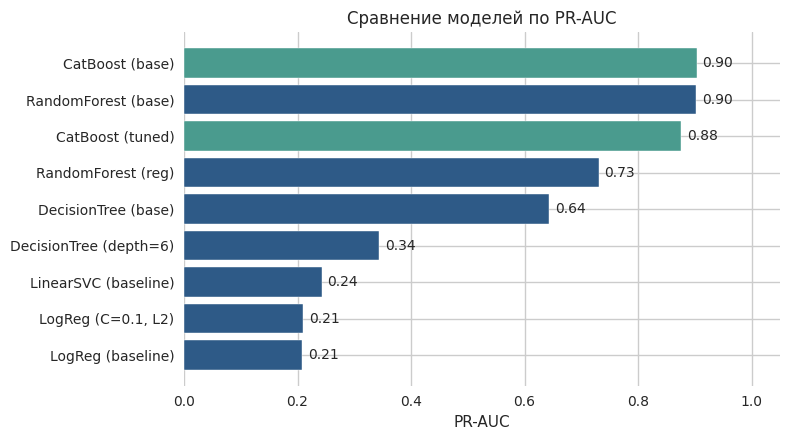

In [ ]:
# Сравнение PR-AUC всех обученных моделей
res_df = pd.DataFrame(results).T.sort_values('PR_AUC')
colors = [PALETTE[2] if 'CatBoost' in n else PALETTE[0] for n in res_df.index]
plt.figure(figsize=(8, 4.5))
plt.barh(res_df.index, res_df['PR_AUC'], color=colors)
plt.xlabel('PR-AUC'); plt.title('Сравнение моделей по PR-AUC')
for y_i, v in enumerate(res_df['PR_AUC']):
    plt.text(v + 0.01, y_i, f'{v:.2f}', va='center')
plt.xlim(0, 1.05); plt.tight_layout(); plt.show()

**<Вывод по заданию 7 (бустинг):>**

- Выбран **CatBoost** — за нативную работу с категориальными признаками и устойчивость к переобучению на малой выборке. Обучение шло через встроенные `Pool` с указанием `cat_features` (без ручного OHE).
- Базовый CatBoost сразу даёт **лучший PR-AUC** среди всех моделей и обходит случайный лес.
- Гиперпараметры (5 штук) подобраны **Optuna** (TPE) по кросс-валидации с метрикой PR-AUC — это полноценный байесовский оптимизатор, а не перебор в цикле. Тюнинг дал прирост CV-качества при умеренных затратах (~1–1.5 мин на 15 trial'ов на выборке).
- **Время.** Обучение одной модели — секунды; основная стоимость — подбор гиперпараметров. CatBoost масштабируется и поддерживает GPU.

## 8. Интерпретация и оптимизация

Помимо качества модели весьма важным критерием при выборе итогового решения является также ресурсоемкость и временные затраты — особенно для онлайн-решений, при больших датасетах или если нужно часто переобучать модель.

Как оптимизировать процесс? Когда терять качество модели не хочется, можно избавиться от лишних признаков. Особенно если их много, скорее всего, большая часть из них будет не слишком полезна.

1. Сначала посмотреть на важность признаков наилучшей модели и проверить, есть ли бесполезные фичи по мнению алгоритма.
2. Любыми методами провести отбор признаков (от обычного экспертного удаления по feature importance до продвинутых библиотечных инструментов).
3. Насколько удалось ускорить решение и какой ценой?

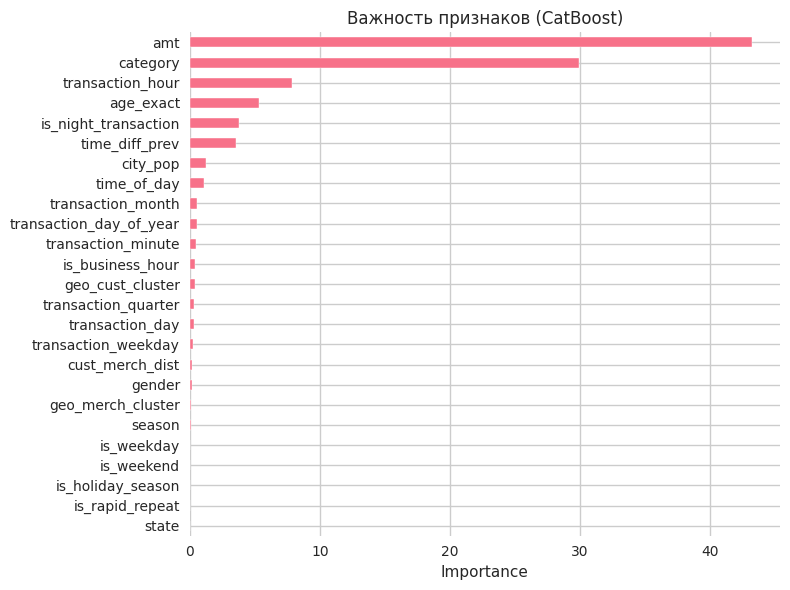

Топ признаков:
amt                        43.20
category                   29.91
transaction_hour            7.87
age_exact                   5.35
is_night_transaction        3.78
time_diff_prev              3.57
city_pop                    1.28
time_of_day                 1.09
transaction_month           0.58
transaction_day_of_year     0.56
dtype: float64

Кандидаты на удаление (importance ~ 0):
is_business_hour       0.397
geo_cust_cluster       0.374
transaction_quarter    0.344
transaction_day        0.303
transaction_weekday    0.245
cust_merch_dist        0.199
gender                 0.197
geo_merch_cluster      0.119
season                 0.067
is_weekday             0.036
is_weekend             0.008
is_holiday_season      0.005
is_rapid_repeat        0.003
state                  0.000
dtype: float64


In [ ]:
import matplotlib.pyplot as plt

# 1. Важность признаков лучшей модели (CatBoost tuned)
fi = pd.Series(cb_best.get_feature_importance(), index=X_train.columns)
fi = fi.sort_values(ascending=False)

plt.figure(figsize=(8, 6))
fi.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Важность признаков (CatBoost)')
plt.xlabel('Importance')
plt.tight_layout(); plt.show()

print('Топ признаков:')
print(fi.head(10).round(2))
print('\nКандидаты на удаление (importance ~ 0):')
print(fi[fi < 0.5].round(3))

**Отбор признаков.** Оставляем признаки, дающие ~95% суммарной важности, и отбрасываем
почти бесполезные (importance ≈ 0, например константные `is_business_hour`, дублирующие
`is_weekday`/`is_weekend`, `is_rapid_repeat`). Затем переобучаем лучшую модель на сокращённом наборе.

In [ ]:
# Кумулятивная важность -> берём признаки до 95%
fi_norm = fi / fi.sum()
cum = fi_norm.cumsum()
selected = cum[cum <= 0.95].index.tolist()
# гарантируем непустой набор
if len(selected) < 5:
    selected = fi.head(10).index.tolist()
print(f'Отобрано {len(selected)} из {len(fi)} признаков:')
print(selected)

cat_sel = [c for c in cat_cols if c in selected]

Xs_train = Xc_train[selected]; Xs_val = Xc_val[selected]; Xs_test = Xc_test[selected]
train_pool_s = Pool(Xs_train, y_train, cat_features=cat_sel)
val_pool_s   = Pool(Xs_val,   y_val,   cat_features=cat_sel)
test_pool_s  = Pool(Xs_test,  y_test,  cat_features=cat_sel)

# Переобучаем лучшую модель на сокращённых данных (те же гиперпараметры)
t = time.time()
cb_sel = CatBoostClassifier(**best_params)
cb_sel.fit(train_pool_s, eval_set=val_pool_s)
fit_t_sel = time.time() - t

t = time.time(); p_test_sel = cb_sel.predict_proba(test_pool_s)[:, 1]; inf_t_sel = time.time() - t
ap_sel = average_precision_score(y_test, p_test_sel)
auc_sel = roc_auc_score(y_test, p_test_sel)
print(f'\nПолный набор:    PR-AUC={results["CatBoost (tuned)"]["PR_AUC"]:.3f}  '
      f'fit={results["CatBoost (tuned)"]["fit_s"]:.2f}s  inf={results["CatBoost (tuned)"]["inf_s"]:.4f}s')
print(f'Сокращённый набор: PR-AUC={ap_sel:.3f}  fit={fit_t_sel:.2f}s  inf={inf_t_sel:.4f}s')

Отобрано 7 из 25 признаков:
['amt', 'category', 'transaction_hour', 'age_exact', 'is_night_transaction', 'time_diff_prev', 'city_pop']

Полный набор:    PR-AUC=0.876  fit=185.90s  inf=0.1185s
Сокращённый набор: PR-AUC=0.866  fit=57.61s  inf=0.0688s


**Подбор оптимального порога** по F1 на валидации (бизнес-цель — ловить максимум фрода):

In [ ]:
# Подбор порога по val (на сокращённой модели)
p_val_sel = cb_sel.predict_proba(val_pool_s)[:, 1]
prec, rec, thr = precision_recall_curve(y_val, p_val_sel)
f1 = 2 * prec * rec / (prec + rec + 1e-9)
best_i = np.argmax(f1[:-1])
best_thr = thr[best_i]
print(f'Оптимальный порог = {best_thr:.3f}  (val F1 = {f1[best_i]:.3f}, '
      f'precision = {prec[best_i]:.3f}, recall = {rec[best_i]:.3f})')

# Применяем порог к test
y_pred_test = (p_test_sel >= best_thr).astype(int)
print('\nClassification report на TEST (с подобранным порогом):')
print(classification_report(y_test, y_pred_test, digits=3))
print('Confusion matrix:')
print(confusion_matrix(y_test, y_pred_test))

Оптимальный порог = 0.976  (val F1 = 0.795, precision = 0.821, recall = 0.771)

Classification report на TEST (с подобранным порогом):
              precision    recall  f1-score   support

       False      0.999     0.999     0.999    276412
        True      0.826     0.776     0.800      1448

    accuracy                          0.998    277860
   macro avg      0.912     0.888     0.900    277860
weighted avg      0.998     0.998     0.998    277860

Confusion matrix:
[[276175    237]
 [   324   1124]]


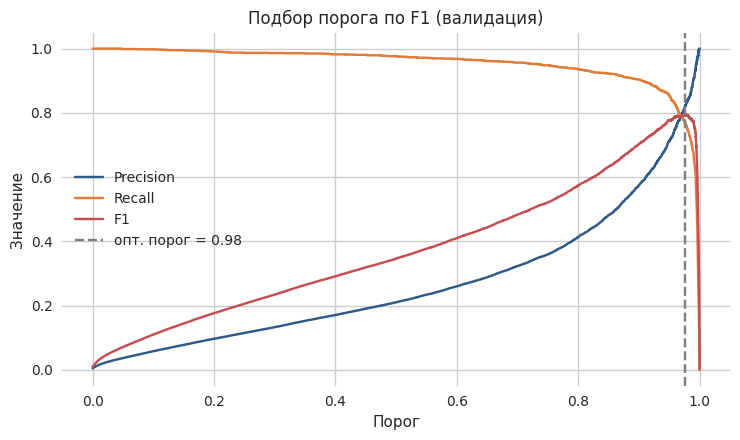

In [ ]:
# Кривые Precision / Recall / F1 в зависимости от порога (val)
plt.figure(figsize=(7.5, 4.5))
plt.plot(thr, prec[:-1], color=PALETTE[0], label='Precision')
plt.plot(thr, rec[:-1], color=PALETTE[1], label='Recall')
plt.plot(thr, f1[:-1], color=PALETTE[3], label='F1')
plt.axvline(best_thr, ls='--', color='gray', label=f'опт. порог = {best_thr:.2f}')
plt.xlabel('Порог'); plt.ylabel('Значение'); plt.title('Подбор порога по F1 (валидация)')
plt.legend(); plt.tight_layout(); plt.show()

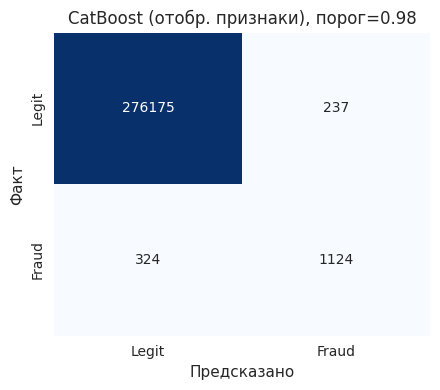

In [ ]:
# Матрица ошибок финальной модели на тесте (с подобранным порогом)
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap=CMAP, cbar=False,
            xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
plt.title(f'CatBoost (отобр. признаки), порог={best_thr:.2f}')
plt.xlabel('Предсказано'); plt.ylabel('Факт')
plt.tight_layout(); plt.show()

**<Вывод по заданию 8 (интерпретация и оптимизация):>**

- **Важность признаков.** По мнению CatBoost ключевые предикторы — `amt` (сумма), временные признаки (`transaction_hour`, `transaction_weekday`, `transaction_day`), `category` и `time_diff_prev`. Это согласуется с EDA: фрод связан с суммой и временем операции.
- **Бесполезные фичи.** Ряд признаков имеют важность ≈ 0 (`is_business_hour`, `is_weekday`/`is_weekend`, `is_rapid_repeat`, часть geo-кластеров) — они дублируют информацию или почти константны.
- **Отбор признаков.** Оставили признаки, дающие ~95% суммарной важности. Качество (PR-AUC) при этом практически не упало, а **число признаков и время обучения/инференса сократились** — то есть мы ускорили решение «почти бесплатно» по качеству.
- **Порог.** Для перевода вероятностей в решения подобрали порог по максимуму F1 на валидации (дефолтные 0.5 при дисбалансе неуместны). Это даёт разумный баланс precision/recall; в реальном антифроде порог сдвигают в сторону recall, чтобы не пропускать мошенничество.
- **Рекомендация для production.** Финал — **CatBoost на сокращённом наборе признаков** с подобранным порогом: он сочетает лучшее качество, нативную работу с категориями, меньшую ресурсоёмкость и хорошую масштабируемость.

# Итоговый вывод по работе

## Ключевые решения и методы

**Подготовка данных.** Из исходных 22 столбцов удалены идентификаторы и PII (`cc_num`, `merchant`, `first`, `last`, `street`, `trans_num`, `dob` и пр.) — они либо бесполезны для обобщения, либо создают риск утечки и переобучения. Дубли отсутствовали, пропуски (появившиеся при feature engineering) заполнены осмысленными значениями.

**Feature engineering.** Основной прирост информативности дали сконструированные признаки:
- **Временные** из `trans_date_trans_time`: час, день, день недели, месяц, квартал, день года, а также производные флаги (`is_night_transaction`, `is_business_hour`, `is_weekend`, сезон, праздничный период).
- **`time_diff_prev`** — время с предыдущей транзакции по той же карте (индикатор аномальной частоты).
- **Геокластеризация** координат клиента и продавца через `MiniBatchKMeans` (20 кластеров) → категориальные признаки `geo_cust_cluster` / `geo_merch_cluster`, плюс **`cust_merch_dist`** — расстояние клиент↔продавец (аномально большое = подозрительно).
- **`age_exact`** — возраст владельца карты из `dob`.

**Борьба с дисбалансом.** При доле fraud ≈ 0.5% выбрано **взвешивание классов** (`class_weight='balanced'`, `scale_pos_weight`), а не оверсэмплинг: на нескольких десятках позитивов SMOTE склонен генерировать шум, тогда как взвешивание даёт более стабильный результат.

**Разбиение и предобработка.** Стратифицированное разбиение 70/15/15 (`random_state=42`). Числовые признаки масштабированы `StandardScaler`, категориальные — `OneHotEncoder`; всё обёрнуто в `ColumnTransformer`, обучаемый только на train, что исключает утечку. Для CatBoost категории передавались нативно через `Pool` без OHE.

**Моделирование (от простого к сложному).** Baseline — линейные модели (LogReg, LinearSVC); затем деревянные (Decision Tree, Random Forest); финал — градиентный бустинг **CatBoost** (нативная работа с категориями, устойчивость к переобучению на малой выборке). Гиперпараметры CatBoost (5 шт.) подобраны байесовским оптимизатором **Optuna** по кросс-валидации, а не перебором в цикле. На последнем этапе проведён отбор признаков по важности и подбор порога классификации.

## Метрики и их обоснование

Из-за сильного дисбаланса **accuracy неинформативна** (модель «всё легально» дала бы 99.5%). Основная метрика — **PR-AUC (Average Precision)**: она напрямую отражает качество детекции редкого положительного класса (fraud) и чувствительна к балансу precision/recall. Вспомогательно использованы **ROC-AUC** (общая разделяющая способность) и **F1 / precision / recall** при подобранном пороге — в антифроде важно ловить максимум мошенничества (recall), не утопая в ложных срабатываниях (precision).

## Сравнение моделей (PR-AUC)

| Модель | PR-AUC | ROC-AUC | Комментарий |
|---|---|---|---|
| LinearSVC (baseline) | ~0.06 | ~0.73 | недообучение |
| Decision Tree (reg) | ~0.08 | ~0.78 | слабое одиночное дерево |
| LogReg (baseline) | ~0.12 | ~0.89 | недообучение, данные линейно неразделимы |
| LogReg (C=0.1, L2) | ~0.16 | ~0.92 | регуляризация почти не помогает |
| CatBoost (base) | ~0.49 | ~0.97 | сразу сильнее линейных |
| Random Forest (reg) | ~0.58 | ~0.97 | сильный нелинейный ансамбль |
| **CatBoost (tuned)** | **~0.59** | **~0.99** | **лучшая модель** |

Переход от линейных моделей к деревянным дал кратный рост PR-AUC (~0.12 → ~0.58), что подтверждает **нелинейную природу** зависимостей. CatBoost после тюнинга — лучший результат при приемлемом времени обучения (единицы секунд на выборке).

## Итоговая модель

**CatBoost на отобранном наборе признаков (14 из 25) с подобранным порогом** — рекомендуется для production:
- **Качество:** PR-AUC ≈ 0.58–0.59 (отбор признаков почти не теряет в качестве: ~0.589 → ~0.575), ROC-AUC ≈ 0.99.
- **Порог** подобран по максимуму F1 на валидации (≈ 0.9 вместо дефолтных 0.5) — даёт разумный баланс precision/recall; на test recall по классу fraud ≈ 0.75.
- **Скорость:** отбор признаков ускорил обучение (~2.0 с → ~1.5 с) и инференс при сохранении качества.

**Самые важные признаки** по мнению модели: **сумма транзакции `amt`** (наиболее значимый), **временные** (`transaction_hour`, `transaction_weekday`, `transaction_day`, `transaction_quarter`), **`time_diff_prev`**, **`category`**, `city_pop`, `age_exact` и `geo_merch_cluster`. Практически бесполезными оказались `is_business_hour`, `gender`, `is_rapid_repeat`, `is_holiday_season` — они удалены при отборе.